# OMIE Data Validation & Structural Statistics

**Purpose:** Exploratory only — not thesis output.

1. Spot-validate prices against the OMIE website
2. Spot-validate aggregate supply/demand curves
3. Structural statistics around the MTU15 reforms

Reform dates:
- Intraday auctions + continuous: **2025-03-19**
- Day-ahead market: **2025-10-01**

## Contents

| § | Title | Data |
|---|---|---|
| 1 | Price spot-validation | `marginalpdbc` |
| 2 | Aggregate curve spot-validation | `curva_pbc` |
| 3 | Structural statistics | `marginalpdbc`, `marginalpibc` |
| · | 3a. Within-day price profile | |
| · | 3b. Intra-hour price dispersion | |
| · | 3c. Monthly price level | |
| · | 3d. IDA prices across regimes | |
| 4 | Continuous intraday market — prices | `precios_pibcic_ronda` |
| 5 | Continuous intraday matched power | `pibcic` |
| · | 5a. Daily matched volume over time | |
| · | 5a-bis. Raw MW-sum vs MWh artefact | |
| · | 5b. Volume profile by period | |
| · | 5c. Intra-hour volume dispersion | |
| · | 5d. Round-level activity | |
| 6 | Continuous intraday accumulated programs | `pibcac` |
| · | 6a. Daily last-round accumulated volume | |
| · | 6b. Accumulated position profile by hour | |
| · | 6c. Round-by-round accumulation | |
| 7 | Day-ahead offers by technology | `cab`, `det`, `lista_unidades` |
| · | 7a. Sell-side offer volume over time | |
| · | 7b. Merit order: bid price distribution | |
| · | 7c. Within-day bid price variability | |
| · | 7d. Intraday offer profile by technology | |
| 8 | Continuous intraday order book | `orders` |
| · | 8a. Limit-price distribution by side | |
| · | 8b. Execution-condition breakdown | |
| · | 8c. Submitted prices vs. clearing price | |
| 9 | Interconnection capacity | `capacidad_inter_pbc`, `capacidad_inter_pvp` |
| 10 | XBID matched transactions | `trades` |
| 11 | Firm concentration across markets | `pdbce`, `pibcie`, `pibcice` |
| · | 11a. Monthly HHI and Top-5 share | |
| 12 | Supply-function slope at clearing price | `curva_pbc`, `marginalpdbc` |
| · | 12a. Monthly slope $\hat\sigma_t$ | |

In [1]:
from pathlib import Path
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

PROJECT_ROOT = Path("../").resolve()

MARGINALPDBC        = PROJECT_ROOT / "data/processed/omie/mercado_diario/precios/marginalpdbc_all.parquet"
MARGINALPIBC        = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_subastas/precios/marginalpibc_all.parquet"
CURVA_PBC_DIR       = PROJECT_ROOT / "data/processed/omie/mercado_diario/curvas/curva_pbc"
CAPACIDAD_INTER_PBC = PROJECT_ROOT / "data/processed/omie/mercado_diario/capacidades/capacidad_inter_pbc_all.parquet"
CAPACIDAD_INTER_PVP = PROJECT_ROOT / "data/processed/omie/mercado_diario/capacidades/capacidad_inter_pvp_all.parquet"
TRADES              = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_continuo/transacciones/trades_all.parquet"

# Structural breaks (all dates = first day of new regime)
IDA_REFORM       = pd.Timestamp("2024-06-14")  # 6 MIBEL sessions → 3 European IDA sessions
ISP15_REFORM     = pd.Timestamp("2024-12-01")  # REE imbalance settlement period → MTU15 (EU Reg 2017/2195)
INTRADAY_REFORM  = pd.Timestamp("2025-03-19")  # MTU60 → MTU15 for intraday auctions + continuous
DAY_AHEAD_REFORM = pd.Timestamp("2025-10-01")  # MTU60 → MTU15 for day-ahead market

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


---
## Section 1 — Price spot-validation

Data: `marginalpdbc_all.parquet` — the day-ahead uniform-price auction (OMIE, Iberian peninsula).

**Market-clearing condition.** The auction clears at the unique marginal price $p^*_t$ (EUR/MWh) for delivery period $t$, defined as the intersection of the aggregate supply and demand step functions:

$$p^*_t = \inf\bigl\{p \geq 0 : Q^S_t(p) \geq Q^D_t(p)\bigr\}$$

When the Portugal–Spain interconnection is not binding, a single Iberian price clears ($p^*_{\text{ES},t} = p^*_{\text{PT},t}$). When the interconnection is congested, the two zones decouple.

Compare with: https://www.omie.es/es/market-results/daily/daily-market/day-ahead-price


In [2]:
CHECK_DATE = "2026-04-10"  # <-- change to any date to spot-check

df = pd.read_parquet(MARGINALPDBC)
day = df[df["date"] == CHECK_DATE].sort_values("period")[["period", "price_es_eur_mwh", "price_pt_eur_mwh"]]

print(f"Date: {CHECK_DATE}  |  MTU: {df.loc[df['date']==CHECK_DATE, 'mtu_minutes'].iloc[0]} min  |  Periods: {len(day)}")
print(day.to_string(index=False))

Date: 2026-04-10  |  MTU: 15 min  |  Periods: 96
 period  price_es_eur_mwh  price_pt_eur_mwh
      1             54.70             54.70
      2             51.20             51.20
      3             47.12             47.12
      4             38.90             38.90
      5             39.90             39.90
      6             38.90             38.90
      7             39.64             39.64
      8             39.51             39.51
      9             39.89             39.89
     10             39.77             39.77
     11             39.77             39.77
     12             39.77             39.77
     13             39.77             39.77
     14             39.77             39.77
     15             39.77             39.77
     16             39.89             39.89
     17             39.77             39.77
     18             39.89             39.89
     19             39.89             39.89
     20             39.90             39.90
     21             39.89  

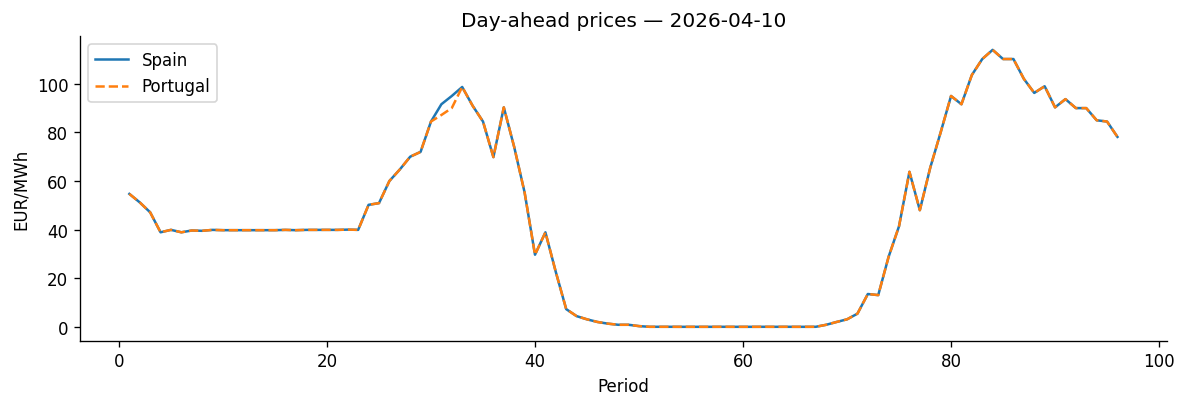

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(day["period"], day["price_es_eur_mwh"], label="Spain", linewidth=1.5)
ax.plot(day["period"], day["price_pt_eur_mwh"], label="Portugal", linewidth=1.5, linestyle="--")
ax.set_xlabel("Period")
ax.set_ylabel("EUR/MWh")
ax.set_title(f"Day-ahead prices — {CHECK_DATE}")
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 2 — Aggregate curve spot-validation

Data: `curva_pbc` — OMIE publishes the full aggregate supply and demand step functions for each period.

**Step-function representation.** The aggregate supply curve is:

$$Q^S_t(p) = \sum_{i \in \mathcal{I}} q_{i,t}\,\mathbf{1}[s_{i,t} \leq p]$$

where $q_{i,t}$ is the quantity offered by unit $i$ in period $t$ and $s_{i,t}$ is the submitted bid price (step threshold). Note that $s_{i,t}$ need not equal marginal cost — firms may bid strategically. The demand curve $Q^D_t(p)$ is the mirror: offered purchase quantities sorted by willingness to pay. The equilibrium price $p^*_t$ is where the two curves intersect.

Compare with: https://www.omie.es/es/market-results/daily/daily-market/aggragate-suply-curves


In [4]:
CHECK_DATE_CURVE = "2026-04-08"  # <-- change to any date
CHECK_PERIOD     = 20            # <-- period number (1-24 for MTU60, 1-96 for MTU15)

# country='MI' = Iberian market aggregate curve (what OMIE shows on the website).
# country='ES'/'PT' only appear post-reform for periods with market splitting (price separation).
glob = str(CURVA_PBC_DIR / "*.parquet")
df_curve = duckdb.query(
    f"SELECT * FROM read_parquet('{glob}', union_by_name=true) "
    f"WHERE date='{CHECK_DATE_CURVE}' AND period_num={CHECK_PERIOD} AND country='MI'"
).df()

print(f"Rows for date={CHECK_DATE_CURVE}, period={CHECK_PERIOD}, country=MI: {len(df_curve)}")
print(df_curve[["offer_type", "curve_type", "power_mw", "price_eur_mwh"]].head(10))

Rows for date=2026-04-08, period=20, country=MI: 3949
  offer_type curve_type  power_mw  price_eur_mwh
0          C          O     120.2         1500.0
1          C          O     329.0         1500.0
2          C          O      19.2         1500.0
3          C          O    1612.8          501.0
4          C          O      14.7          501.0
5          C          O     210.4          501.0
6          C          O      43.3          500.0
7          C          O     230.3          500.0
8          C          O     143.2          500.0
9          C          O     272.4          500.0


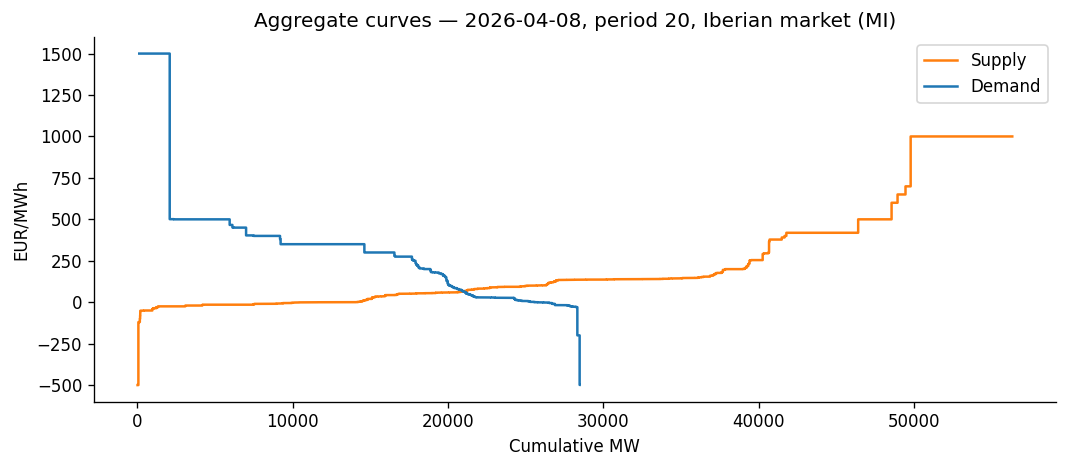

In [5]:
def build_staircase(df_steps, price_col="price_eur_mwh", power_col="power_mw", ascending=True):
    """Sort steps by price and compute cumulative MW."""
    s = df_steps.sort_values(price_col, ascending=ascending).copy()
    s["cum_mw"] = s[power_col].cumsum()
    return s

supply = build_staircase(
    df_curve[(df_curve["offer_type"] == "V") & (df_curve["curve_type"] == "O")],
    ascending=True,
)
demand = build_staircase(
    df_curve[(df_curve["offer_type"] == "C") & (df_curve["curve_type"] == "O")],
    ascending=False,  # demand curve: high prices first
)

fig, ax = plt.subplots(figsize=(9, 4))
if not supply.empty:
    ax.step(supply["cum_mw"], supply["price_eur_mwh"], where="post", label="Supply", color="tab:orange")
if not demand.empty:
    ax.step(demand["cum_mw"], demand["price_eur_mwh"], where="post", label="Demand", color="tab:blue")
ax.set_xlabel("Cumulative MW")
ax.set_ylabel("EUR/MWh")
ax.set_title(f"Aggregate curves — {CHECK_DATE_CURVE}, period {CHECK_PERIOD}, Iberian market (MI)")
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 3 — Structural statistics

> **Note on price levels:** Price changes reflect renewable growth, regulation, and the MTU15 day-ahead reform simultaneously. Price-level comparisons are not clean reform signals. Focus on *structural* metrics.

**Reform regimes** for the day-ahead market:

| Regime | Period | MTU $\delta$ | Periods/day |
|---|---|---|---|
| Pre-reform | before 2025-10-01 | 60 min | 24 |
| Post-reform | from 2025-10-01 | 15 min | 96 |

The key structural question is whether the finer $\delta = 15$ min resolution reveals price variation that was previously averaged away within each hour.


In [6]:
# Load full price dataset once
df_prices = pd.read_parquet(MARGINALPDBC)
df_prices["date"] = pd.to_datetime(df_prices["date"])
print(f"marginalpdbc: {len(df_prices):,} rows, {df_prices['date'].min().date()} → {df_prices['date'].max().date()}")

marginalpdbc: 86,447 rows, 2018-01-01 → 2026-04-11


### 3a. Within-day price profile

**Within-day price profile.** For regime $r \in \{\text{pre}, \text{post}\}$, the mean price at period $\pi$ is:

$$\bar{p}^r_\pi = \frac{1}{|T_r|} \sum_{t \in T_r} p^*_{t,\pi}$$

where $T_r$ is the set of trading days in regime $r$. Pre-reform, $\pi \in \{1,\ldots,24\}$ (hours). Post-reform, $\pi \in \{1,\ldots,96\}$ (quarter-hours). The profile reveals the daily demand cycle — ramps, peak, and off-peak — at the resolution available in each regime.


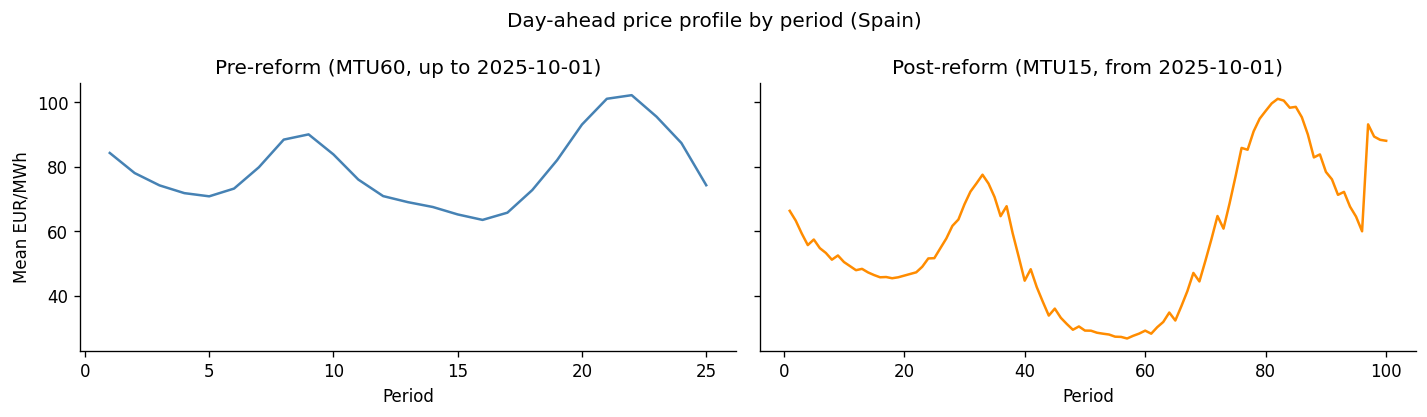

In [7]:
pre  = df_prices[df_prices["date"] < DAY_AHEAD_REFORM]
post = df_prices[df_prices["date"] >= DAY_AHEAD_REFORM]

pre_profile  = pre.groupby("period")["price_es_eur_mwh"].mean()
post_profile = post.groupby("period")["price_es_eur_mwh"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
axes[0].plot(pre_profile.index,  pre_profile.values,  linewidth=1.5, color="steelblue")
axes[0].set_title(f"Pre-reform (MTU60, up to {DAY_AHEAD_REFORM.date()})")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Mean EUR/MWh")

axes[1].plot(post_profile.index, post_profile.values, linewidth=1.5, color="darkorange")
axes[1].set_title(f"Post-reform (MTU15, from {DAY_AHEAD_REFORM.date()})")
axes[1].set_xlabel("Period")

plt.suptitle("Day-ahead price profile by period (Spain)", fontsize=12)
plt.tight_layout()
plt.show()

### 3b. Intra-hour price dispersion — core MTU15-DA metric

**Intra-hour dispersion.** Post-reform only. Each hour $h \in \{1,\ldots,24\}$ contains four quarter-hour periods $Q_h = \{4(h-1)+1,\ldots,4h\}$. The intra-hour price standard deviation for day $t$ and hour $h$ is:

$$\sigma_{t,h} = \sqrt{\frac{1}{4}\sum_{\pi \in Q_h}\bigl(p^*_{t,\pi} - \bar{p}_{t,h}\bigr)^2}, \quad \bar{p}_{t,h} = \frac{1}{4}\sum_{\pi \in Q_h} p^*_{t,\pi}$$

The reported metric is the mean across days: $\bar{\sigma}_h = \frac{1}{|T_{\text{post}}|}\sum_t \sigma_{t,h}$. Under hourly trading this variation is invisible — the reform reveals it.


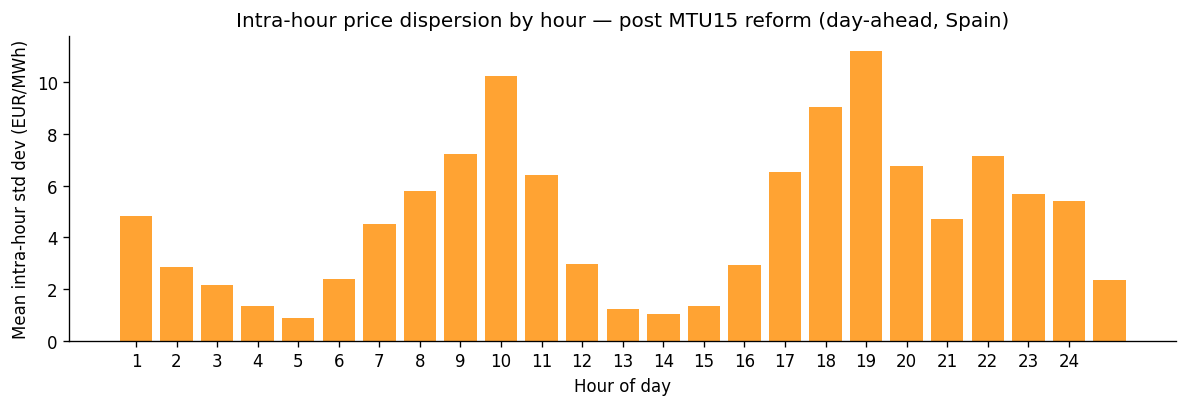

Overall mean intra-hour std dev: 4.68 EUR/MWh
Max (hour 19): 11.23 EUR/MWh


In [8]:
post_mtu15 = df_prices[(df_prices["date"] >= DAY_AHEAD_REFORM) & (df_prices["mtu_minutes"] == 15)].copy()
# Map period (1-96) to hour-of-day (1-24)
post_mtu15["hour"] = ((post_mtu15["period"] - 1) // 4) + 1

# Std dev of 4 quarter-hour prices within each (date, hour)
intra_hour_std = (
    post_mtu15.groupby(["date", "hour"])["price_es_eur_mwh"]
    .std()
    .reset_index()
    .groupby("hour")["price_es_eur_mwh"]
    .mean()  # average across days
)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(intra_hour_std.index, intra_hour_std.values, color="darkorange", alpha=0.8)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean intra-hour std dev (EUR/MWh)")
ax.set_title("Intra-hour price dispersion by hour — post MTU15 reform (day-ahead, Spain)")
ax.set_xticks(range(1, 25))
plt.tight_layout()
plt.show()

print(f"Overall mean intra-hour std dev: {intra_hour_std.mean():.2f} EUR/MWh")
print(f"Max (hour {intra_hour_std.idxmax()}): {intra_hour_std.max():.2f} EUR/MWh")

### 3c. Monthly price level

Monthly mean price $\bar{p}_m = \frac{1}{|T_m|}\sum_{t \in T_m}\frac{1}{|\Pi_t|}\sum_\pi p^*_{t,\pi}$, where $T_m$ are days in month $m$ and $\Pi_t$ are delivery periods of day $t$.

Price level context only — **not a clean reform signal**. Renewables penetration, gas prices, and hydro conditions all move simultaneously. The reform date lines are shown for reference.


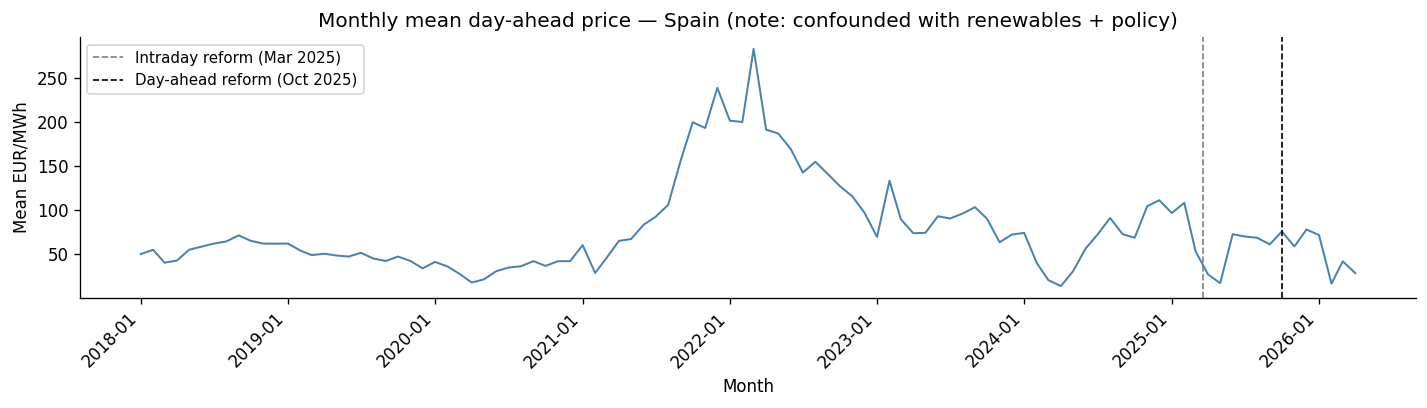

In [9]:
monthly = (
    df_prices.groupby(df_prices["date"].dt.to_period("M"))["price_es_eur_mwh"]
    .mean()
    .reset_index()
)
monthly["date"] = monthly["date"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(monthly["date"], monthly["price_es_eur_mwh"], linewidth=1.2, color="steelblue")
ax.axvline(INTRADAY_REFORM,  color="gray",   linestyle="--", linewidth=1, label="Intraday reform (Mar 2025)")
ax.axvline(DAY_AHEAD_REFORM, color="black",  linestyle="--", linewidth=1, label="Day-ahead reform (Oct 2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Mean EUR/MWh")
ax.set_title("Monthly mean day-ahead price — Spain (note: confounded with renewables + policy)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 3d. Intraday auction prices across regimes

Three regimes in `marginalpibc`:

| Regime | Period | Sessions | MTU $\delta$ |
|---|---|---|---|
| Pre-IDA | before 2024-06-14 | 6 (MIBEL) | 60 min |
| IDA MTU60 | 2024-06-14 – 2025-03-18 | 3 (IDA1–3) | 60 min |
| IDA MTU15 | from 2025-03-19 | 3 (IDA1–3) | 15 min |

**Cross-session convergence.** If intraday trading efficiently incorporates new information across sessions, prices should converge over the day. The mean cross-session standard deviation is:

$$\bar{\sigma}^{\text{cross}} = \frac{1}{|T_r|} \sum_{t \in T_r} \operatorname{std}_{s}\bigl(\bar{p}_{t,s}\bigr)$$

where $\bar{p}_{t,s}$ is the mean price across all periods in session $s$ on day $t$. Note: IDA3 covers only afternoon delivery (D+12h–24h), so some days legitimately have 2 sessions.


── Intraday reform (MTU15-IDA auctions) (reform: 2025-03-19) ──
  Before (2025-02-19 → 2025-03-18): mean=78.82, median=79.18, std=38.91 EUR/MWh  (n=28 days)
  After  (2025-03-19 → 2025-04-18): mean=26.33, median=14.00, std=34.92 EUR/MWh  (n=31 days)
  Change: -66.6%



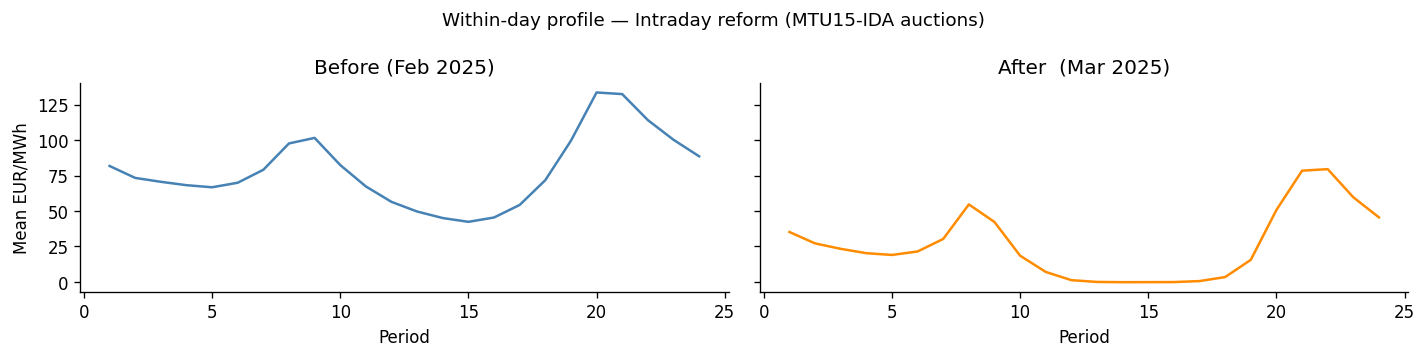

── Day-ahead reform (MTU15 day-ahead) (reform: 2025-10-01) ──
  Before (2025-09-01 → 2025-09-30): mean=61.04, median=66.63, std=42.90 EUR/MWh  (n=30 days)
  After  (2025-10-01 → 2025-10-31): mean=75.75, median=83.61, std=44.55 EUR/MWh  (n=31 days)
  Change: +24.1%



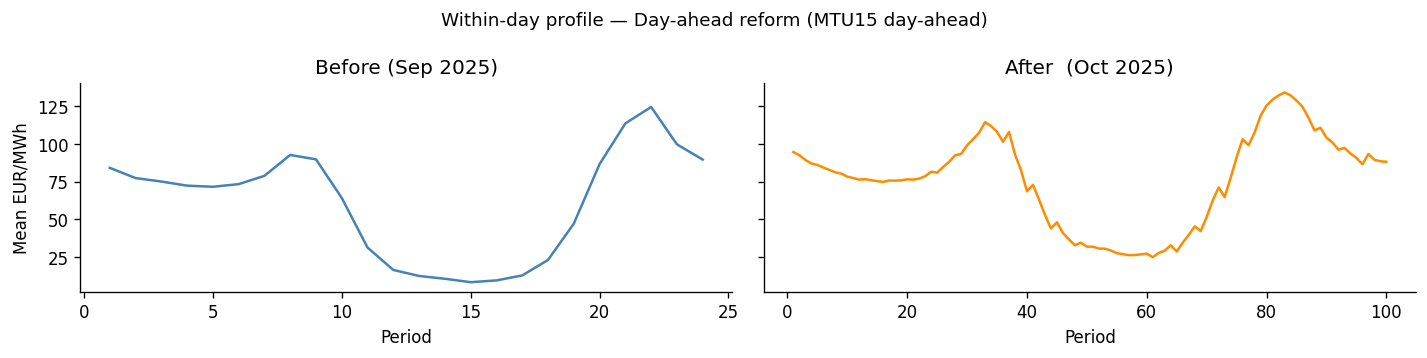

In [10]:
from dateutil.relativedelta import relativedelta

def compare_around_reform(df, reform_date, label, window_months=1):
    before = df[
        (df["date"] >= reform_date - relativedelta(months=window_months)) &
        (df["date"] <  reform_date)
    ]
    after = df[
        (df["date"] >= reform_date) &
        (df["date"] <  reform_date + relativedelta(months=window_months))
    ]
    print(f"── {label} (reform: {reform_date.date()}) ──")
    print(f"  Before ({before['date'].min().date()} → {before['date'].max().date()}): "
          f"mean={before['price_es_eur_mwh'].mean():.2f}, "
          f"median={before['price_es_eur_mwh'].median():.2f}, "
          f"std={before['price_es_eur_mwh'].std():.2f} EUR/MWh  (n={before['date'].nunique()} days)")
    print(f"  After  ({after['date'].min().date()} → {after['date'].max().date()}): "
          f"mean={after['price_es_eur_mwh'].mean():.2f}, "
          f"median={after['price_es_eur_mwh'].median():.2f}, "
          f"std={after['price_es_eur_mwh'].std():.2f} EUR/MWh  (n={after['date'].nunique()} days)")
    pct = (after['price_es_eur_mwh'].mean() - before['price_es_eur_mwh'].mean()) / before['price_es_eur_mwh'].mean() * 100
    print(f"  Change: {pct:+.1f}%\n")

    # Within-day profile comparison (only meaningful if both sides have data)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
    for ax, subset, sublabel, color in [
        (axes[0], before, f"Before ({(reform_date - relativedelta(months=window_months)).strftime('%b %Y')})", "steelblue"),
        (axes[1], after,  f"After  ({reform_date.strftime('%b %Y')})", "darkorange"),
    ]:
        profile = subset.groupby("period")["price_es_eur_mwh"].mean()
        ax.plot(profile.index, profile.values, linewidth=1.5, color=color)
        ax.set_title(sublabel)
        ax.set_xlabel("Period")
    axes[0].set_ylabel("Mean EUR/MWh")
    plt.suptitle(f"Within-day profile — {label}", fontsize=11)
    plt.tight_layout()
    plt.show()

compare_around_reform(df_prices, INTRADAY_REFORM,  "Intraday reform (MTU15-IDA auctions)")
compare_around_reform(df_prices, DAY_AHEAD_REFORM, "Day-ahead reform (MTU15 day-ahead)")

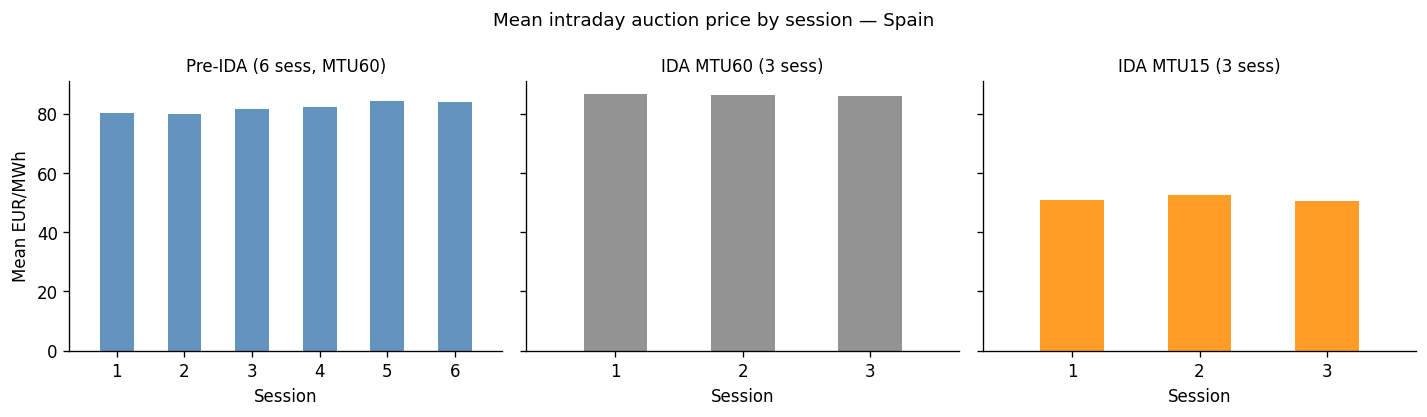

Cross-session price convergence (std dev across sessions per day):
  Pre-IDA (6 sess, MTU60): mean std = 3.48 EUR/MWh  (n = 2351 days with all 6 sessions)
  IDA MTU60 (3 sess): mean std = 6.03 EUR/MWh  (n = 259 days with all 3 sessions)
  IDA MTU15 (3 sess): mean std = 5.62 EUR/MWh  (n = 363 days with all 3 sessions)


In [11]:
IDA_TRANSITION = pd.Timestamp("2024-06-14")  # confirmed from data: last 6-session day was 2024-06-13

df_pibc = pd.read_parquet(MARGINALPIBC)
df_pibc["date"] = pd.to_datetime(df_pibc["date"])

pre_ida   = df_pibc[df_pibc["date"] <  IDA_TRANSITION]
ida_mtu60 = df_pibc[(df_pibc["date"] >= IDA_TRANSITION) & (df_pibc["date"] < INTRADAY_REFORM)]
ida_mtu15 = df_pibc[df_pibc["date"] >= INTRADAY_REFORM]

regimes = [
    ("Pre-IDA (6 sess, MTU60)", pre_ida,   "steelblue",  6),
    ("IDA MTU60 (3 sess)",       ida_mtu60, "gray",       3),
    ("IDA MTU15 (3 sess)",       ida_mtu15, "darkorange", 3),
]

# --- Mean price by session ---
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, (label, subset, color, n_sess) in zip(axes, regimes):
    sess_mean = subset.groupby("session_number")["price_es_eur_mwh"].mean()
    ax.bar(sess_mean.index, sess_mean.values, color=color, alpha=0.85, width=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Session")
    ax.set_xticks(range(1, n_sess + 1))
    ax.set_xlim(0.3, n_sess + 0.7)
axes[0].set_ylabel("Mean EUR/MWh")
plt.suptitle("Mean intraday auction price by session — Spain", fontsize=11)
plt.tight_layout()
plt.show()

# --- Cross-session price convergence (std dev across sessions per day) ---
# Pre-IDA: require all 6 sessions. IDA regimes: require all 3.
# Note: IDA3 only covers afternoon delivery (D 12h–24h), so some days legitimately have 2 sessions.
# Those days are excluded to keep the comparison clean.
print("Cross-session price convergence (std dev across sessions per day):")
for label, subset, color, n_sess in regimes:
    daily_sess = subset.groupby(["date", "session_number"])["price_es_eur_mwh"].mean().reset_index()
    full_days  = daily_sess.groupby("date")["session_number"].count()
    full_days  = full_days[full_days == n_sess].index
    daily_std  = daily_sess[daily_sess["date"].isin(full_days)].groupby("date")["price_es_eur_mwh"].std()
    print(f"  {label}: mean std = {daily_std.mean():.2f} EUR/MWh  (n = {len(daily_std)} days with all {n_sess} sessions)")

---
## Section 4 — Continuous intraday market (`precios_pibcic_ronda`)

Data: `precios_pibcic_ronda_all.parquet` — mean transaction price per round and delivery period in the XBID continuous intraday market.

**Round-price object.** Let $r = 1, 2, \ldots, R_d$ index the trading rounds on day $d$ (approximately 21 rounds/day). For each delivery period $\pi$ and round $r$, OMIE publishes:

$$\bar{p}_{d,r,\pi} = \frac{\sum_k p_k q_k}{\sum_k q_k}$$

the volume-weighted mean transaction price across all trades $k$ executed in round $r$ for delivery period $\pi$ on day $d$. Multiple rounds can trade the same delivery period as the delivery window approaches.

Coverage: **2018-06-13 → 2026-04-09** · 2,857 files · 2,470 MTU60 days + 387 MTU15-IDA days

> **Note:** `precios_pibcic` (the daily aggregate file) has only 2 days downloaded — use `_ronda` instead.


precios_pibcic_ronda: 1,172,276 rows, 2018-06-13 → 2026-04-09
MTU breakdown: {15: 389, 60: 2471} days


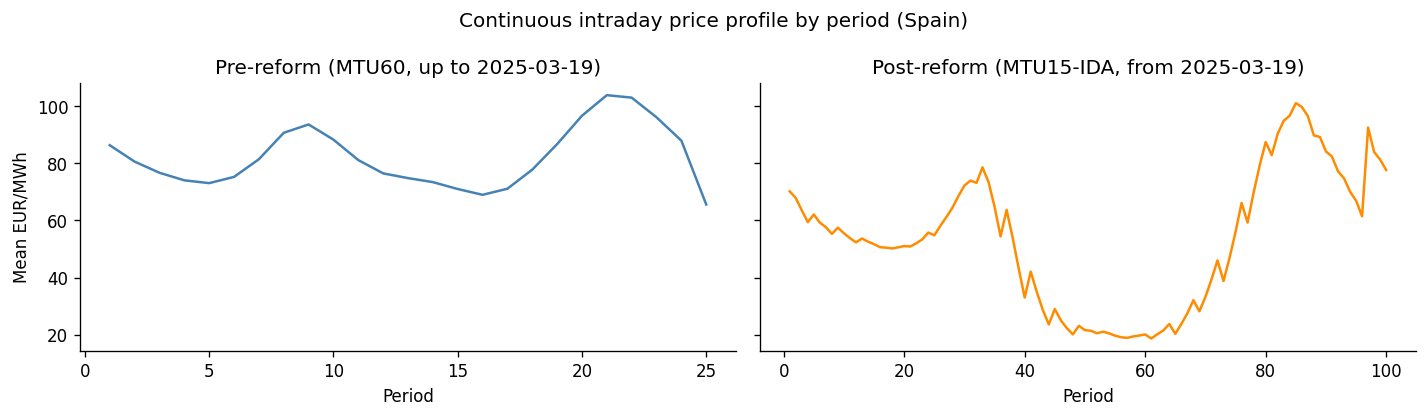

In [12]:
PRECIOS_PIBCIC_RONDA = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_continuo/precios/precios_pibcic_ronda_all.parquet"

df_cont = pd.read_parquet(PRECIOS_PIBCIC_RONDA)
df_cont["date"] = pd.to_datetime(df_cont["date"])
print(f"precios_pibcic_ronda: {len(df_cont):,} rows, {df_cont['date'].min().date()} → {df_cont['date'].max().date()}")
print(f"MTU breakdown: {df_cont.groupby('mtu_minutes')['date'].nunique().to_dict()} days")

# Aggregate across rounds: mean price per (date, period). Rounds are intra-day snapshots of the same delivery period.
period_price = df_cont.groupby(["date", "period", "mtu_minutes"])["price_mean_es_eur_mwh"].mean().reset_index()

pre_cont  = period_price[period_price["date"] <  INTRADAY_REFORM]
post_cont = period_price[period_price["date"] >= INTRADAY_REFORM]

pre_profile  = pre_cont.groupby("period")["price_mean_es_eur_mwh"].mean()
post_profile = post_cont.groupby("period")["price_mean_es_eur_mwh"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
axes[0].plot(pre_profile.index,  pre_profile.values,  linewidth=1.5, color="steelblue")
axes[0].set_title(f"Pre-reform (MTU60, up to {INTRADAY_REFORM.date()})")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Mean EUR/MWh")

axes[1].plot(post_profile.index, post_profile.values, linewidth=1.5, color="darkorange")
axes[1].set_title(f"Post-reform (MTU15-IDA, from {INTRADAY_REFORM.date()})")
axes[1].set_xlabel("Period")

plt.suptitle("Continuous intraday price profile by period (Spain)", fontsize=12)
plt.tight_layout()
plt.show()

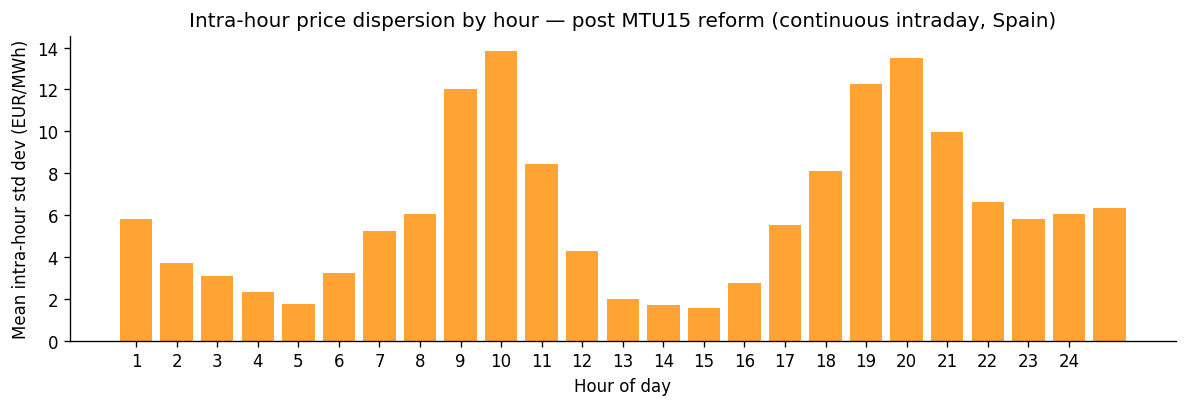

Overall mean intra-hour std dev: 6.08 EUR/MWh
Max (hour 10): 13.86 EUR/MWh


In [13]:
post_mtu15_cont = period_price[(period_price["date"] >= INTRADAY_REFORM) & (period_price["mtu_minutes"] == 15)].copy()
post_mtu15_cont["hour"] = ((post_mtu15_cont["period"] - 1) // 4) + 1

intra_hour_std_cont = (
    post_mtu15_cont.groupby(["date", "hour"])["price_mean_es_eur_mwh"]
    .std()
    .reset_index()
    .groupby("hour")["price_mean_es_eur_mwh"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(intra_hour_std_cont.index, intra_hour_std_cont.values, color="darkorange", alpha=0.8)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean intra-hour std dev (EUR/MWh)")
ax.set_title("Intra-hour price dispersion by hour — post MTU15 reform (continuous intraday, Spain)")
ax.set_xticks(range(1, 25))
plt.tight_layout()
plt.show()

print(f"Overall mean intra-hour std dev: {intra_hour_std_cont.mean():.2f} EUR/MWh")
print(f"Max (hour {intra_hour_std_cont.idxmax()}): {intra_hour_std_cont.max():.2f} EUR/MWh")

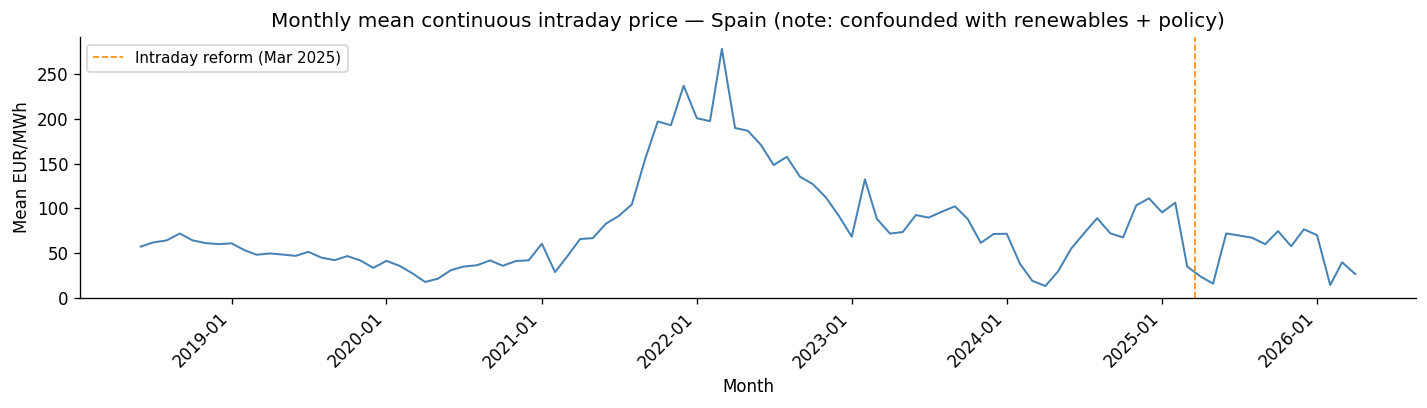

In [14]:
monthly_cont = (
    period_price.groupby(period_price["date"].dt.to_period("M"))["price_mean_es_eur_mwh"]
    .mean()
    .reset_index()
)
monthly_cont["date"] = monthly_cont["date"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(monthly_cont["date"], monthly_cont["price_mean_es_eur_mwh"], linewidth=1.2, color="steelblue")
ax.axvline(INTRADAY_REFORM, color="darkorange", linestyle="--", linewidth=1, label="Intraday reform (Mar 2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Mean EUR/MWh")
ax.set_title("Monthly mean continuous intraday price — Spain (note: confounded with renewables + policy)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## Section 5 — Continuous intraday matched power (`pibcic`)

Data: `pibcic_all.parquet` — assigned power (MW) per unit, round, and delivery period in the XBID continuous intraday market. Each row is a `(date, round_number, period, unit_code)` triplet with `assigned_power_mw` (positive = buy, negative = sell).

**MWh correction.** Because the number of delivery periods per day increases from 24 (MTU60) to 96 (MTU15), the raw sum of MW is mechanically inflated by a factor of 4 post-reform. The energy-equivalent volume is:

$$E_{d} = \sum_{r,\pi,i} \bigl|m_{d,r,\pi,i}\bigr| \cdot \frac{\delta_\pi}{60}$$

where $m_{d,r,\pi,i}$ is the matched power (MW) of unit $i$ in period $\pi$ of round $r$ on day $d$, and $\delta_\pi \in \{15, 60\}$ is the period duration (min). This converts MW-counts to MWh and enables a fair pre/post comparison.

Coverage: **2018-06-13 → 2026-01-10** · 66,134 files · 2,474 MTU60 days + 297 MTU15 days


In [15]:
PIBCIC = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_continuo/programas/pibcic_all.parquet"

df_pibcic = pd.read_parquet(PIBCIC)
df_pibcic["date"] = pd.to_datetime(df_pibcic["date"])
print(f"pibcic: {len(df_pibcic):,} rows, {df_pibcic['date'].min().date()} → {df_pibcic['date'].max().date()}")
print(f"MTU breakdown: {df_pibcic.groupby('mtu_minutes')['date'].nunique().to_dict()} days")
print(f"Unique units:  {df_pibcic['unit_code'].nunique()}")
print(f"Round range:   {df_pibcic['round_number'].min()} – {df_pibcic['round_number'].max()}")

pibcic: 11,795,924 rows, 2018-06-13 → 2026-01-10
MTU breakdown: {15: 297, 60: 2474} days
Unique units:  2862
Round range:   1 – 25


### 5a. Daily matched volume and round activity over time

Daily gross energy traded: $E_d = \sum_{r,\pi,i} |m_{d,r,\pi,i}| \cdot \delta_\pi / 60$ (MWh).  
Active rounds per day: $R_d = |\{r : \exists\, i, \pi \text{ s.t. } m_{d,r,\pi,i} \neq 0\}|$.


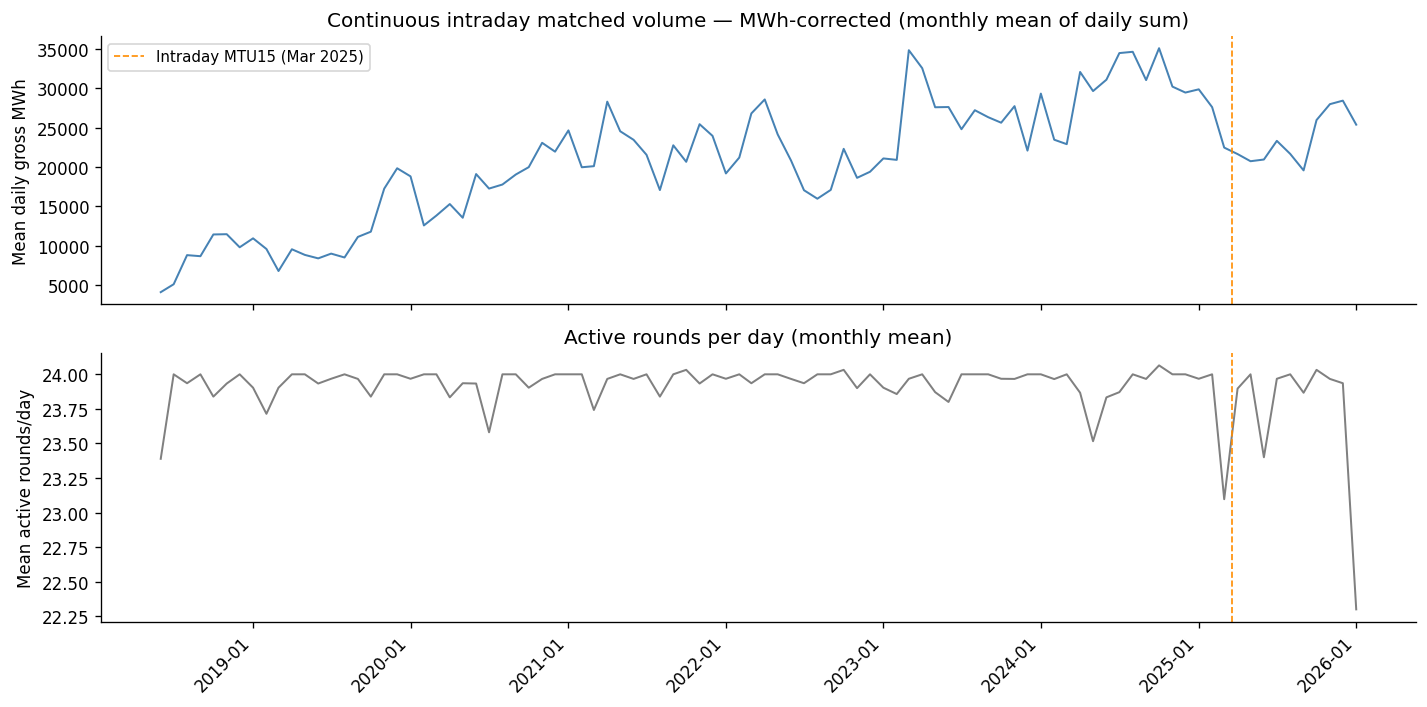

Mean daily gross MWh and active rounds by regime:
  Pre-MTU15-IDA  (< 2025-03-19): gross_mwh=20,708  active_rounds=23.9  (n=2471 days)
  Post-MTU15-IDA (≥ 2025-03-19): gross_mwh=23,134  active_rounds=23.8  (n=297 days)


In [16]:
# MWh-corrected volume: |MW| × (mtu_minutes/60) removes the mechanical 4× inflation
# from having 96 periods/day post-reform instead of 24 pre-reform.
df_pibcic["gross_mwh"] = df_pibcic["assigned_power_mw"].abs() * df_pibcic["mtu_minutes"] / 60

daily = df_pibcic.groupby("date").agg(
    gross_mwh=("gross_mwh", "sum"),
    active_rounds=("round_number", "nunique"),
).reset_index()

monthly_pibcic = daily.groupby(daily["date"].dt.to_period("M")).agg(
    gross_mwh=("gross_mwh", "mean"),
    active_rounds=("active_rounds", "mean"),
).reset_index()
monthly_pibcic["date"] = monthly_pibcic["date"].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(monthly_pibcic["date"], monthly_pibcic["gross_mwh"], linewidth=1.2, color="steelblue")
axes[0].axvline(INTRADAY_REFORM, color="darkorange", linestyle="--", linewidth=1, label="Intraday MTU15 (Mar 2025)")
axes[0].set_ylabel("Mean daily gross MWh")
axes[0].set_title("Continuous intraday matched volume — MWh-corrected (monthly mean of daily sum)")
axes[0].legend(fontsize=9)

axes[1].plot(monthly_pibcic["date"], monthly_pibcic["active_rounds"], linewidth=1.2, color="gray")
axes[1].axvline(INTRADAY_REFORM, color="darkorange", linestyle="--", linewidth=1)
axes[1].set_ylabel("Mean active rounds/day")
axes[1].set_title("Active rounds per day (monthly mean)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Mean daily gross MWh and active rounds by regime:")
for label, mask in [
    ("Pre-MTU15-IDA  (< 2025-03-19)", daily["date"] < INTRADAY_REFORM),
    ("Post-MTU15-IDA (≥ 2025-03-19)", daily["date"] >= INTRADAY_REFORM),
]:
    sub = daily[mask]
    print(f"  {label}: gross_mwh={sub['gross_mwh'].mean():,.0f}  active_rounds={sub['active_rounds'].mean():.1f}  (n={len(sub)} days)")


### 5a-bis. Raw MW-sum vs MWh — the mechanical MTU15-IDA artefact

The raw MW-sum $\sum_\pi |m_{d,r,\pi,i}|$ doubles at the reform because there are $4\times$ more period rows per day under MTU15-IDA. The MWh-corrected series $E_d$ (shown in 5a) divides each term by $\delta_\pi/60$, removing this inflation:

$$\underbrace{\sum_\pi |m_{d,\pi}|}_{\text{inflated MW-sum}} \;\approx\; 4 \times \underbrace{\sum_\pi |m_{d,\pi}| \cdot \tfrac{\delta_\pi}{60}}_{\text{corrected MWh}} \quad \text{(post-reform)}$$

This cell shows both side by side to make the mechanical artefact explicit.


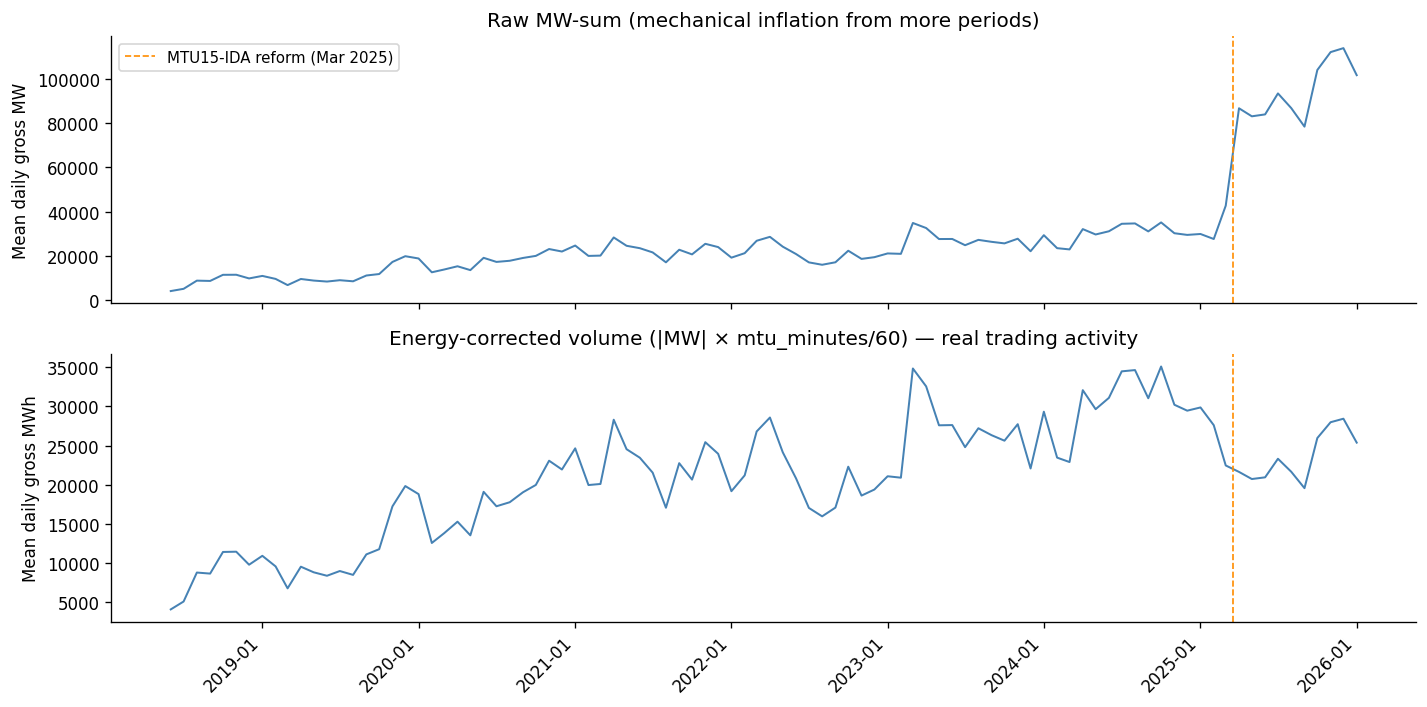

Regime                             Gross MW    Gross MWh   Days
----------------------------------------------------------------
Pre-MTU15-IDA  (< 2025-03-19)        20,708       20,708   2471
Post-MTU15-IDA (≥ 2025-03-19)        92,534       23,134    297

Post/pre ratio — MW-sum: 4.47x   MWh: 1.12x
(If MWh ratio ≈ MW ratio: break is real. If MWh ratio ≈ 1: purely mechanical.)


In [17]:
# Energy-equivalent: MWh = |MW| × (mtu_minutes / 60)
df_pibcic["gross_mwh"] = df_pibcic["assigned_power_mw"].abs() * df_pibcic["mtu_minutes"] / 60

daily_energy = df_pibcic.groupby("date").agg(
    gross_mw=("assigned_power_mw", lambda x: x.abs().sum()),
    gross_mwh=("gross_mwh", "sum"),
).reset_index()

monthly_energy = daily_energy.groupby(daily_energy["date"].dt.to_period("M")).agg(
    gross_mw=("gross_mw", "mean"),
    gross_mwh=("gross_mwh", "mean"),
).reset_index()
monthly_energy["date"] = monthly_energy["date"].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(monthly_energy["date"], monthly_energy["gross_mw"], linewidth=1.2, color="steelblue")
axes[0].axvline(INTRADAY_REFORM, color="darkorange", linestyle="--", linewidth=1, label="MTU15-IDA reform (Mar 2025)")
axes[0].set_ylabel("Mean daily gross MW")
axes[0].set_title("Raw MW-sum (mechanical inflation from more periods)")
axes[0].legend(fontsize=9)

axes[1].plot(monthly_energy["date"], monthly_energy["gross_mwh"], linewidth=1.2, color="steelblue")
axes[1].axvline(INTRADAY_REFORM, color="darkorange", linestyle="--", linewidth=1)
axes[1].set_ylabel("Mean daily gross MWh")
axes[1].set_title("Energy-corrected volume (|MW| × mtu_minutes/60) — real trading activity")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Regime means
print(f"{'Regime':<30} {'Gross MW':>12} {'Gross MWh':>12} {'Days':>6}")
print("-" * 64)
for label, mask in [
    ("Pre-MTU15-IDA  (< 2025-03-19)", daily_energy["date"] < INTRADAY_REFORM),
    ("Post-MTU15-IDA (≥ 2025-03-19)", daily_energy["date"] >= INTRADAY_REFORM),
]:
    sub = daily_energy[mask]
    print(f"{label:<30} {sub['gross_mw'].mean():>12,.0f} {sub['gross_mwh'].mean():>12,.0f} {len(sub):>6}")

ratio_mw  = daily_energy[daily_energy["date"] >= INTRADAY_REFORM]["gross_mw"].mean()  / daily_energy[daily_energy["date"] < INTRADAY_REFORM]["gross_mw"].mean()
ratio_mwh = daily_energy[daily_energy["date"] >= INTRADAY_REFORM]["gross_mwh"].mean() / daily_energy[daily_energy["date"] < INTRADAY_REFORM]["gross_mwh"].mean()
print(f"\nPost/pre ratio — MW-sum: {ratio_mw:.2f}x   MWh: {ratio_mwh:.2f}x")
print(f"(If MWh ratio ≈ MW ratio: break is real. If MWh ratio ≈ 1: purely mechanical.)")

### 5b. Matched volume profile by period — pre vs post MTU15-IDA

**Net position per hour.** To compare across MTU regimes, map each delivery period $\pi$ to an hour $h(\pi)$:

$$h(\pi) = \begin{cases} \pi & \text{if MTU60} \\ \lceil \pi / 4 \rceil & \text{if MTU15} \end{cases}$$

Then sum signed matched power within each $(d, h)$ and take the absolute value before averaging across days:

$$\bar{A}_h = \frac{1}{|T_r|} \sum_{t \in T_r} \left| \sum_{\pi : h(\pi)=h} \sum_{r,i} m_{t,r,\pi,i} \right|$$

This collapses the four quarter-hour positions into a single hourly net position, enabling a direct shape comparison between regimes.


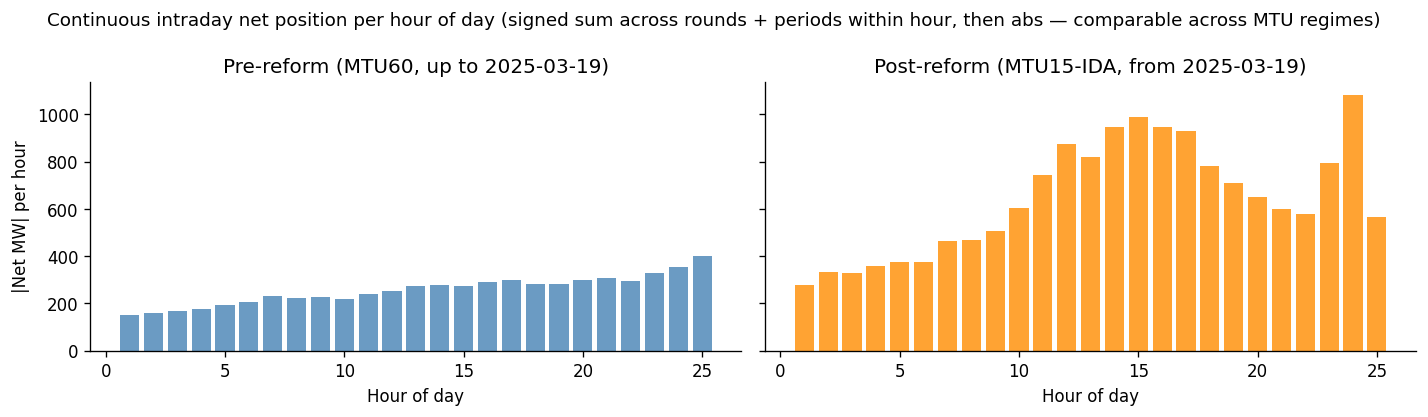

In [18]:
# Aggregate net position to hour-of-day for a fair pre/post comparison.
# Pre-reform: period == hour (1-24). Post-reform: hour = (period-1)//4 + 1.
# Within each (date, hour) sum signed MW across periods, then abs — avoids
# artificially inflating the post-reform profile by counting 4 periods vs 1.
net_period = df_pibcic.groupby(["date", "period"])["assigned_power_mw"].sum().reset_index(name="net_mw")

pre_df  = net_period[net_period["date"] < INTRADAY_REFORM].copy()
post_df = net_period[net_period["date"] >= INTRADAY_REFORM].copy()

pre_df["hour"]  = pre_df["period"]               # MTU60: period == hour
post_df["hour"] = (post_df["period"] - 1) // 4 + 1  # MTU15-IDA: 4 periods per hour

# Sum signed MW within each (date, hour), then abs
pre_hourly  = pre_df.groupby(["date", "hour"])["net_mw"].sum().abs().groupby("hour").mean()
post_hourly = post_df.groupby(["date", "hour"])["net_mw"].sum().abs().groupby("hour").mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
axes[0].bar(pre_hourly.index,  pre_hourly.values,  color="steelblue",  alpha=0.8)
axes[0].set_title(f"Pre-reform (MTU60, up to {INTRADAY_REFORM.date()})")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("|Net MW| per hour")

axes[1].bar(post_hourly.index, post_hourly.values, color="darkorange", alpha=0.8)
axes[1].set_title(f"Post-reform (MTU15-IDA, from {INTRADAY_REFORM.date()})")
axes[1].set_xlabel("Hour of day")

plt.suptitle("Continuous intraday net position per hour of day (signed sum across rounds + periods within hour, then abs — comparable across MTU regimes)", fontsize=11)
plt.tight_layout()
plt.show()


### 5c. Intra-hour volume dispersion — post MTU15-IDA

Post-reform, each hour $h$ maps to four delivery periods $Q_h = \{4(h-1)+1,\ldots,4h\}$. The intra-hour dispersion in absolute net position is:

$$\bar{\sigma}^{\text{vol}}_h = \frac{1}{|T_{\text{post}}|} \sum_{t \in T_{\text{post}}} \operatorname{std}_{\pi \in Q_h}\!\bigl(\bigl|\textstyle\sum_{r,i} m_{t,r,\pi,i}\bigr|\bigr)$$

A large $\bar{\sigma}^{\text{vol}}_h$ means matched volumes differ substantially across quarter-hours within hour $h$ — a pattern invisible under MTU60.


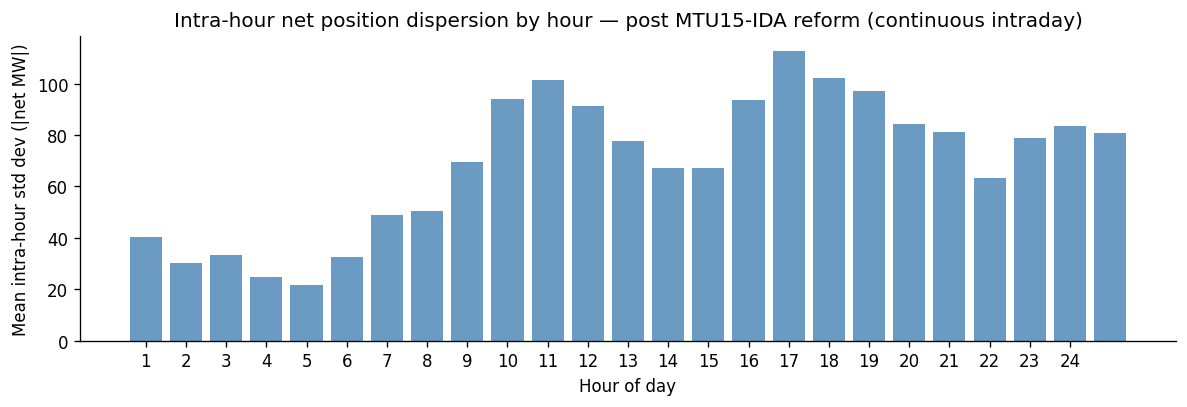

Overall mean intra-hour std dev: 69.1 MW
Max (hour 17): 112.9 MW


In [19]:
post_mtu15_net = net_period[
    (net_period["date"] >= INTRADAY_REFORM) &
    (net_period["date"].isin(df_pibcic[df_pibcic["mtu_minutes"] == 15]["date"].unique()))
].copy()
post_mtu15_net["abs_net_mw"] = post_mtu15_net["net_mw"].abs()
post_mtu15_net["hour"] = ((post_mtu15_net["period"] - 1) // 4) + 1

intra_hour_std_net = (
    post_mtu15_net.groupby(["date", "hour"])["abs_net_mw"]
    .std()
    .reset_index()
    .groupby("hour")["abs_net_mw"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(intra_hour_std_net.index, intra_hour_std_net.values, color="steelblue", alpha=0.8)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean intra-hour std dev (|net MW|)")
ax.set_title("Intra-hour net position dispersion by hour — post MTU15-IDA reform (continuous intraday)")
ax.set_xticks(range(1, 25))
plt.tight_layout()
plt.show()

print(f"Overall mean intra-hour std dev: {intra_hour_std_net.mean():.1f} MW")
print(f"Max (hour {intra_hour_std_net.idxmax()}): {intra_hour_std_net.max():.1f} MW")


### 5d. Round-level activity — matched volume per round, pre vs post MTU15-IDA

**Round-level energy.** For each day $d$ and round $r$, the gross energy matched in that round is:

$$E_{d,r} = \sum_{\pi, i} |m_{d,r,\pi,i}| \cdot \frac{\delta_\pi}{60}$$

The mean across days, $\bar{E}_r = \frac{1}{|T|}\sum_d E_{d,r}$, shows which rounds carry the most trading activity. Early rounds capture the bulk of pre-positioning; late rounds reflect last-minute rebalancing as the delivery window approaches.


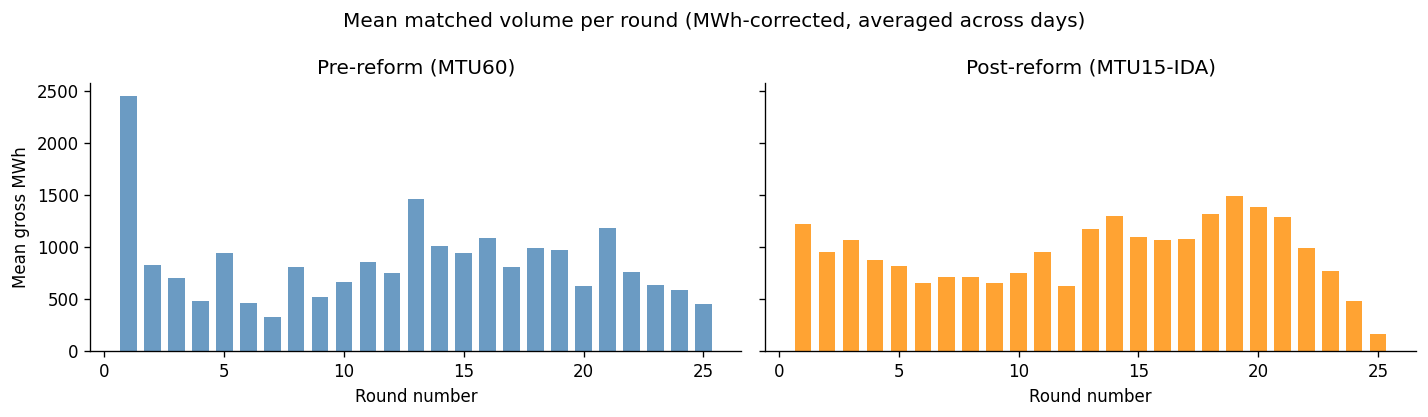

Top 5 rounds by mean matched MWh (pre-reform):
round_number
1     2450.406458
13    1457.179029
21    1176.774818
16    1085.783043
14    1006.489273

Top 5 rounds by mean matched MWh (post-reform):
round_number
19    1486.852778
20    1383.965741
18    1318.170118
14    1289.801627
21    1286.801431


In [20]:
# Round-level matched volume in MWh (|MW| × mtu_minutes/60).
# Using MWh corrects for the 4× more periods per round post-reform.
df_pibcic["gross_mwh"] = df_pibcic["assigned_power_mw"].abs() * df_pibcic["mtu_minutes"] / 60

round_vol = df_pibcic.groupby(["date", "round_number"])["gross_mwh"].sum().reset_index(name="gross_mwh")

pre_round  = round_vol[round_vol["date"] < INTRADAY_REFORM].groupby("round_number")["gross_mwh"].mean()
post_round = round_vol[round_vol["date"] >= INTRADAY_REFORM].groupby("round_number")["gross_mwh"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
axes[0].bar(pre_round.index,  pre_round.values,  color="steelblue",  alpha=0.8, width=0.7)
axes[0].set_title("Pre-reform (MTU60)")
axes[0].set_xlabel("Round number")
axes[0].set_ylabel("Mean gross MWh")

axes[1].bar(post_round.index, post_round.values, color="darkorange", alpha=0.8, width=0.7)
axes[1].set_title("Post-reform (MTU15-IDA)")
axes[1].set_xlabel("Round number")

plt.suptitle("Mean matched volume per round (MWh-corrected, averaged across days)", fontsize=12)
plt.tight_layout()
plt.show()

print("Top 5 rounds by mean matched MWh (pre-reform):")
print(pre_round.nlargest(5).to_string())
print()
print("Top 5 rounds by mean matched MWh (post-reform):")
print(post_round.nlargest(5).to_string())


### 5d — Note: the last-round spike

**Why round 24 (pre-reform) and the last round (post-reform) carry so much volume:**
The XBID market closes sequentially, approximately 30 minutes before each delivery period. Final position adjustments pile into the last active round as delivery approaches. Round 24 in the pre-reform chart is the last active round for hour 24 (23:00–24:00) — the final delivery hour of the day — when participants make their last rebalancing move.

**Cross-day hypothesis (does pre-reform round 25 = round 1 of next day?):**
OMIE’s continuous market opens for a new delivery day before midnight. If a file for delivery date $d$ contains rows with `round_number >= 25`, those could be early trading rounds for the first delivery periods of day $d+1$ that were attributed to day $d$. The cell below checks this.


In [21]:
# §5d investigation: does round_number > 24 in pre-reform correspond to next-day delivery?
pre_df_inv = df_pibcic[df_pibcic["date"] < INTRADAY_REFORM][["date", "round_number", "period"]].copy()

max_rnd_pre = pre_df_inv["round_number"].max()
print(f"Max round_number in pre-reform pibcic: {max_rnd_pre}")
print()
print("Round-number frequency (pre-reform, top 10 by count):")
print(pre_df_inv.groupby("round_number").size().sort_values(ascending=False).head(10).rename("n_rows").to_string())

if max_rnd_pre >= 25:
    high_rnd = pre_df_inv[pre_df_inv["round_number"] >= 25]
    print(f"\nRecords with round_number >= 25: {len(high_rnd):,}")
    print("Period distribution in those records (top 10):")
    print(high_rnd["period"].value_counts().head(10).to_string())
    pct_p1 = (high_rnd["period"] == 1).mean() * 100
    print(f"\nFraction at period=1 (first delivery slot, possible next-day): {pct_p1:.1f}%")
else:
    print("No round_number >= 25 found in pre-reform data. Spike is within-day last-minute rebalancing.")


Max round_number in pre-reform pibcic: 25

Round-number frequency (pre-reform, top 10 by count):
round_number
1     570261
13    427430
21    416670
18    368275
5     345826
19    317744
16    315324
11    312235
14    311704
8     311398

Records with round_number >= 25: 174
Period distribution in those records (top 10):
period
25    80
3     14
5      7
2      6
19     6
20     6
21     6
23     6
4      5
10     5

Fraction at period=1 (first delivery slot, possible next-day): 2.3%


---
## Section 6 — Continuous intraday accumulated programs (`pibcac`)

Data: `pibcac_all.parquet` — cumulative scheduled MW per unit after each round. Unlike PIBCIC (incremental change per round), each PIBCAC snapshot contains the **full accumulated position** for every unit × period at the end of round $r$:

$$A_{d,r,\pi,i} = \sum_{r' \leq r} m_{d,r',\pi,i}$$

**2.7 billion rows** — 59,299 files, 2018-06-13 → 2026-01-10.

> **Data availability gap**: OMIE ZIP archives for 2025-04 through 2025-12 return HTTP 500 — those months are not publicly available. Post-reform coverage is limited to 2025-03-19 → 2025-03-31 (13 days) and 2026-01-01 → 2026-01-10 (10 days). Cross-regime comparisons should be interpreted with caution.

> **Interpretive caveat**: PIBCAC records only *matched* power. Rejected offers are not observed. Total matched volume is bounded by system demand.


In [22]:
PIBCAC = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_continuo/programas/pibcac_all.parquet"

# Load via DuckDB — too large for full in-memory pandas
con_ac = duckdb.connect()

# Sample check
info = con_ac.execute(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT date) AS n_days,
        MIN(date) AS date_min,
        MAX(date) AS date_max,
        COUNT(DISTINCT unit_code) AS n_units
    FROM read_parquet('{PIBCAC}')
""").fetchone()
print(f"Rows: {info[0]:,}  Days: {info[1]}  Range: {info[2]} -> {info[3]}  Units: {info[4]}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 2,691,641,468  Days: 2480  Range: 2018-06-13 -> 2026-01-10  Units: 5567


### 6a. Daily last-round accumulated volume over time

The final settled state on day $d$ is the position at the last round $R_d = \max_r$. Total accumulated volume (MWh-corrected):

$$V_d = \sum_{\pi, i} \bigl|A_{d,R_d,\pi,i}\bigr| \cdot \frac{\delta_\pi}{60}$$

This is the total energy scheduled through the continuous intraday market as of market close.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

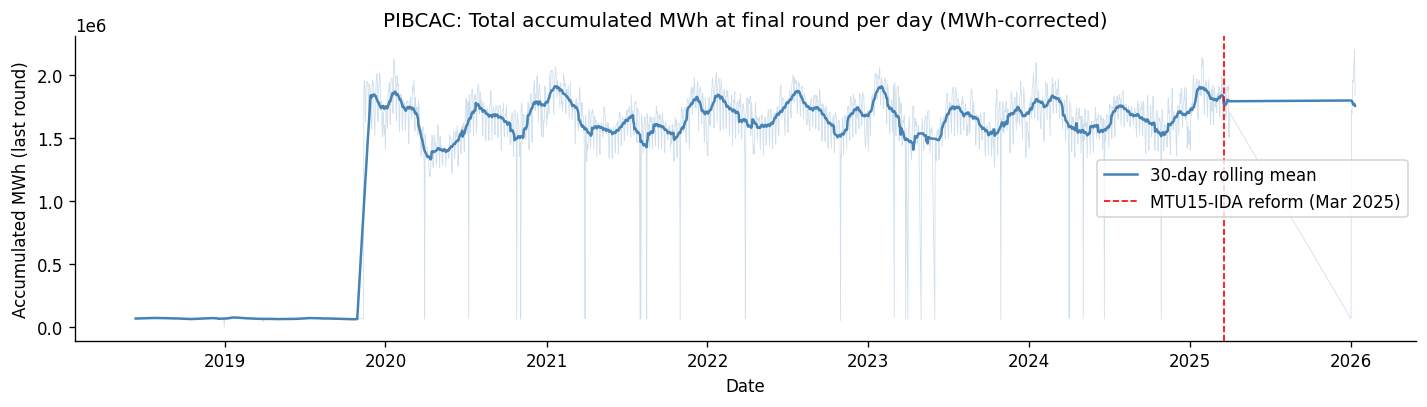

Pre-reform mean:  1,327,853 MWh
Post-reform mean: 1,795,048 MWh
Ratio (post/pre): 1.35x
(Ratio ~1 = no change in matched energy; MWh corrects for extra periods post-reform)


In [23]:
# MWh-corrected: multiply |MW| by mtu_minutes/60 to remove the mechanical 4× inflation
# from 96 periods/day (MTU15) vs 24 (MTU60).
daily_last = con_ac.execute(f"""
    WITH last_round AS (
        SELECT date, MAX(round_number) AS last_round
        FROM read_parquet('{PIBCAC}')
        GROUP BY date
    )
    SELECT p.date,
           SUM(ABS(p.assigned_power_mw) * p.mtu_minutes / 60.0) AS total_mwh
    FROM read_parquet('{PIBCAC}') p
    JOIN last_round l ON p.date = l.date AND p.round_number = l.last_round
    GROUP BY p.date
    ORDER BY p.date
""").df()

daily_last["date"] = pd.to_datetime(daily_last["date"])
daily_last["smoothed"] = daily_last["total_mwh"].rolling(30, center=True, min_periods=7).mean()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(daily_last["date"], daily_last["total_mwh"], alpha=0.25, color="steelblue", linewidth=0.5)
ax.plot(daily_last["date"], daily_last["smoothed"], color="steelblue", linewidth=1.5, label="30-day rolling mean")
ax.axvline(INTRADAY_REFORM, color="red", linestyle="--", linewidth=1, label="MTU15-IDA reform (Mar 2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Accumulated MWh (last round)")
ax.set_title("PIBCAC: Total accumulated MWh at final round per day (MWh-corrected)")
ax.legend()
plt.tight_layout()
plt.show()

pre_mean  = daily_last.loc[daily_last["date"] < INTRADAY_REFORM, "total_mwh"].mean()
post_mean = daily_last.loc[daily_last["date"] >= INTRADAY_REFORM, "total_mwh"].mean()
print(f"Pre-reform mean:  {pre_mean:,.0f} MWh")
print(f"Post-reform mean: {post_mean:,.0f} MWh")
print(f"Ratio (post/pre): {post_mean/pre_mean:.2f}x")
print("(Ratio ~1 = no change in matched energy; MWh corrects for extra periods post-reform)")


### 6b. Accumulated position profile by hour of day — pre vs post MTU15-IDA

**Accumulated position by hour.** Let $A^+_{d,r,\pi,i} = \max(A_{d,r,\pi,i}, 0)$ and
$A^-_{d,r,\pi,i} = \min(A_{d,r,\pi,i}, 0)$ split buy and sell sides. The mean buy (resp. sell)
accumulated MW at the final round $R_d$, by hour of day, is:

$$\bar{A}^{\text{buy}}_h = \frac{1}{|T_r|}\sum_{d \in T_r}\sum_{\substack{\pi:\,h(\pi)=h \\\ i}} A^+_{d,R_d,\pi,i},
\qquad
\bar{A}^{\text{sell}}_h = \frac{1}{|T_r|}\sum_{d \in T_r}\sum_{\substack{\pi:\,h(\pi)=h \\\ i}} \bigl|A^-_{d,R_d,\pi,i}\bigr|$$

where $h(\pi)$ is the hour mapping from §5b and $R_d = \max_r$ is the last round of day $d$.
Both regimes are mapped to hours 1–24. The buy/sell asymmetry by hour reveals which
delivery windows attract the most net trading activity and which hours are most frequently
rebalanced via the continuous market.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

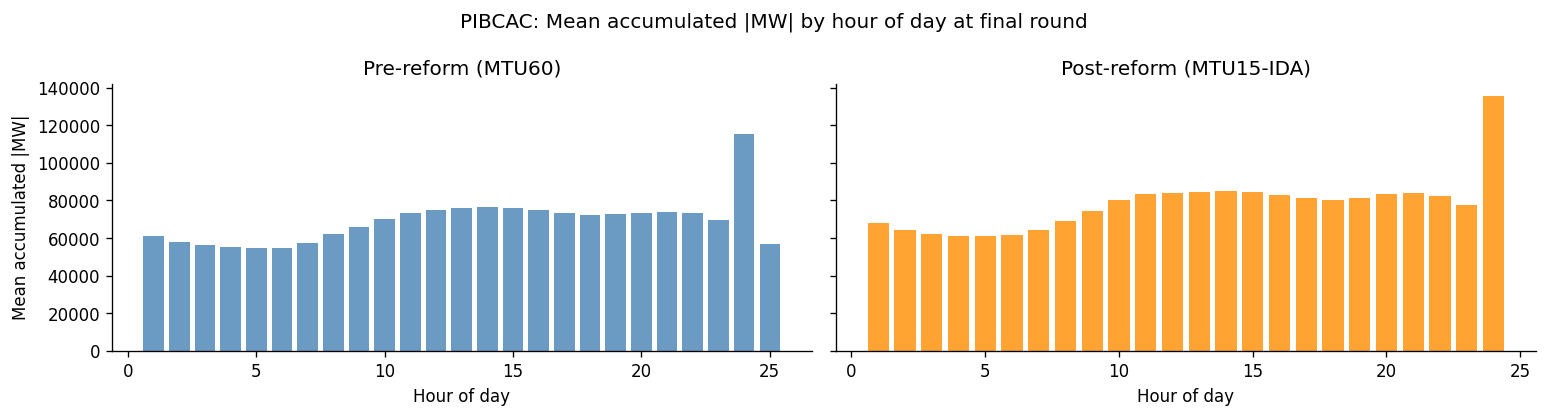

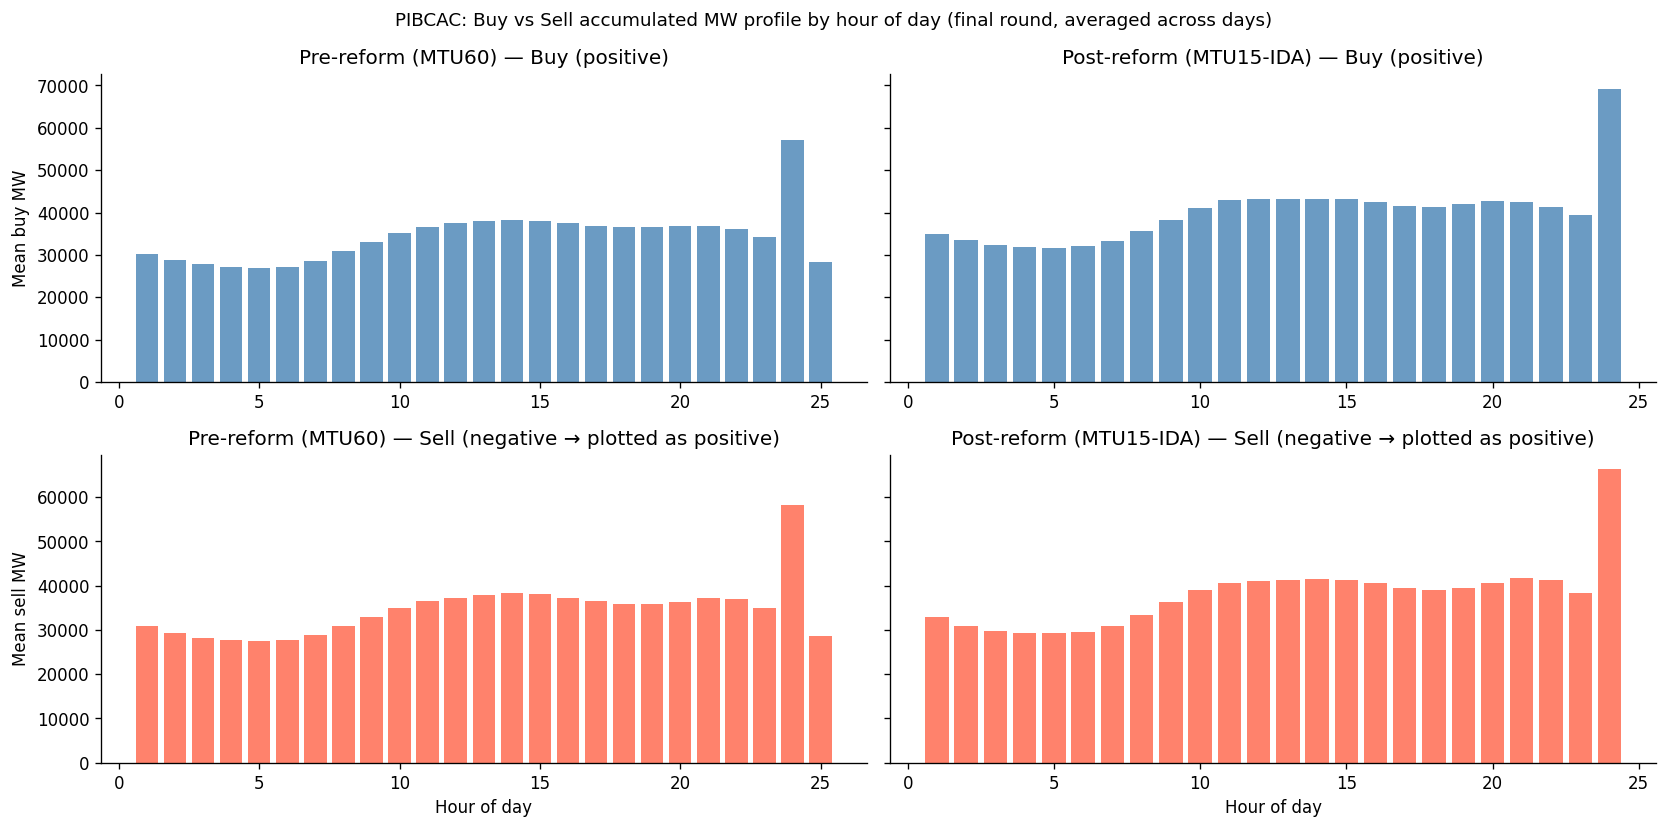

In [24]:
period_profile = con_ac.execute(f"""
    WITH last_round AS (
        SELECT date, MAX(round_number) AS last_round
        FROM read_parquet('{PIBCAC}')
        GROUP BY date
    )
    SELECT p.date, p.period, p.mtu_minutes,
           SUM(CASE WHEN p.assigned_power_mw > 0 THEN  p.assigned_power_mw ELSE 0 END) AS buy_mw,
           SUM(CASE WHEN p.assigned_power_mw < 0 THEN -p.assigned_power_mw ELSE 0 END) AS sell_mw,
           SUM(ABS(p.assigned_power_mw)) AS abs_mw
    FROM read_parquet('{PIBCAC}') p
    JOIN last_round l ON p.date = l.date AND p.round_number = l.last_round
    GROUP BY p.date, p.period, p.mtu_minutes
    ORDER BY p.date, p.period
""").df()

period_profile["date"] = pd.to_datetime(period_profile["date"])

# Map period → hour: MTU60 period==hour; MTU15 hour = (period-1)//4 + 1
period_profile["hour"] = period_profile.apply(
    lambda r: int(r["period"]) if r["mtu_minutes"] == 60 else (int(r["period"]) - 1) // 4 + 1,
    axis=1
)

pre_df  = period_profile[period_profile["date"] < INTRADAY_REFORM]
post_df = period_profile[period_profile["date"] >= INTRADAY_REFORM]

def hourly_mean(df, col):
    return df.groupby(["date", "hour"])[col].mean().groupby("hour").mean()

pre_buy   = hourly_mean(pre_df,  "buy_mw")
pre_sell  = hourly_mean(pre_df,  "sell_mw")
post_buy  = hourly_mean(post_df, "buy_mw")
post_sell = hourly_mean(post_df, "sell_mw")
pre_abs   = hourly_mean(pre_df,  "abs_mw")
post_abs  = hourly_mean(post_df, "abs_mw")

# ── Plot: |MW| profile pre/post (original) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)
axes[0].bar(pre_abs.index,  pre_abs.values,  color="steelblue",  alpha=0.8)
axes[0].set_title("Pre-reform (MTU60)")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Mean accumulated |MW|")
axes[1].bar(post_abs.index, post_abs.values, color="darkorange", alpha=0.8)
axes[1].set_title("Post-reform (MTU15-IDA)")
axes[1].set_xlabel("Hour of day")
plt.suptitle("PIBCAC: Mean accumulated |MW| by hour of day at final round", fontsize=12)
plt.tight_layout()
plt.show()

# ── Plot: buy vs sell profile pre/post ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey="row")
width = 0.4

for col_idx, (regime, buy, sell, label) in enumerate([
    ("Pre-reform (MTU60)",  pre_buy,  pre_sell,  f"up to {INTRADAY_REFORM.date()}"),
    ("Post-reform (MTU15-IDA)", post_buy, post_sell, f"from {INTRADAY_REFORM.date()}"),
]):
    ax_buy  = axes[0][col_idx]
    ax_sell = axes[1][col_idx]
    ax_buy.bar(buy.index,  buy.values,  color="steelblue", alpha=0.8, width=0.8)
    ax_sell.bar(sell.index, sell.values, color="tomato",    alpha=0.8, width=0.8)
    ax_buy.set_title(f"{regime} — Buy (positive)")
    ax_sell.set_title(f"{regime} — Sell (negative → plotted as positive)")
    ax_sell.set_xlabel("Hour of day")
    if col_idx == 0:
        axes[0][0].set_ylabel("Mean buy MW")
        axes[1][0].set_ylabel("Mean sell MW")

plt.suptitle("PIBCAC: Buy vs Sell accumulated MW profile by hour of day (final round, averaged across days)", fontsize=11)
plt.tight_layout()
plt.show()


### 6c. Round-by-round accumulation — how does the schedule build up?

For a representative pre-reform day, plot total accumulated $\sum_{\pi,i} |A_{d,r,\pi,i}|$ after each round $r$.

**Non-monotonicity.** The accumulated $|MW|$ is not necessarily monotone because participants can reduce or cancel their continuous-market positions between rounds:

$$A_{d,r,\pi,i} = A_{d,r-1,\pi,i} + m_{d,r,\pi,i}, \quad m_{d,r,\pi,i} \in \mathbb{R}$$

The common pattern is a gradual reduction in early rounds (net cancellations) followed by a sharp spike in final rounds as end-of-day rebalancing concentrates just before delivery.

**Note:** The x-axis is the sequential round index (1 to ~21), not the delivery period.


Sample day: 2025-03-18 (24 rounds)


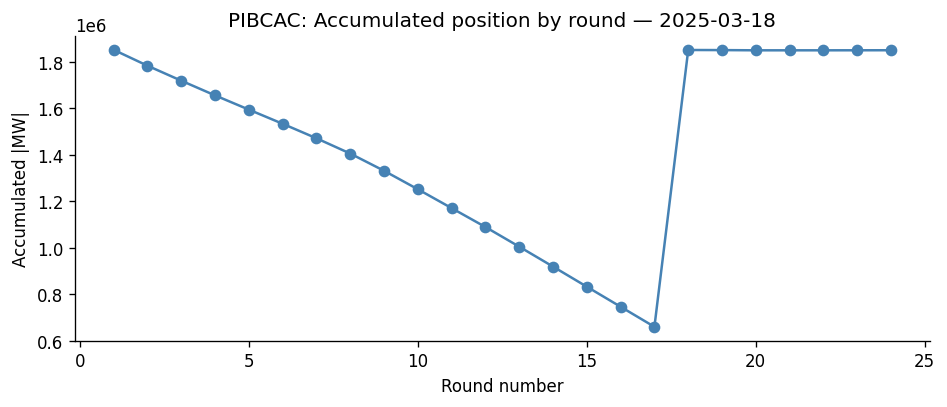

In [25]:
# Pick the most recent day with the most rounds
sample_day_row = con_ac.execute(f"""
    SELECT date, MAX(round_number) AS n_rounds
    FROM read_parquet('{PIBCAC}')
    WHERE date >= '{(INTRADAY_REFORM - pd.Timedelta(days=90)).date()}'
      AND date < '{INTRADAY_REFORM.date()}'
    GROUP BY date
    ORDER BY n_rounds DESC, date DESC
    LIMIT 1
""").fetchone()
sample_day = sample_day_row[0]
print(f"Sample day: {sample_day} ({sample_day_row[1]} rounds)")

round_accum = con_ac.execute(f"""
    SELECT round_number, SUM(ABS(assigned_power_mw)) AS total_abs_mw
    FROM read_parquet('{PIBCAC}')
    WHERE date = '{sample_day}'
    GROUP BY round_number
    ORDER BY round_number
""").df()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(round_accum["round_number"], round_accum["total_abs_mw"], marker="o", color="steelblue")
ax.set_xlabel("Round number")
ax.set_ylabel("Accumulated |MW|")
ax.set_title(f"PIBCAC: Accumulated position by round — {sample_day}")
plt.tight_layout()
plt.show()

---
## Section 7 — Day-ahead offers by technology (`cab` + `det` + `lista_unidades`)

Data: `det_all` (price/quantity per offer × period) joined to `cab_all` (offer headers with `unit_code`), then mapped to technology via `lista_unidades.csv`.

**Technology-level supply curve.** The aggregate offer curve for technology group $g$ in period $\pi$ is:

$$Q^{S,g}_\pi(p) = \sum_{i \in g} q_{i,\pi} \cdot \mathbf{1}[s_{i,\pi} \leq p]$$

Stacking across groups gives the full merit order. The reform moves from $|\Pi| = 24$ to $|\Pi| = 96$, enabling finer intraday price differentiation by technology.

**Coverage:** 2018-01-01 → 2026-01-09. ~25% of historical unit codes are not in the current `lista_unidades` (deactivated units) and appear as **Other/Unknown**. All volume figures use MWh-correction ($\text{MW} \times \delta_\pi / 60$) for pre/post comparability.


In [26]:
CAB   = PROJECT_ROOT / "data/processed/omie/mercado_diario/ofertas/cab_all.parquet"
DET   = PROJECT_ROOT / "data/processed/omie/mercado_diario/ofertas/det_all.parquet"
UNITS = PROJECT_ROOT / "data/external/omie_reference/lista_unidades.csv"

con_det = duckdb.connect()

TECH_SQL = """CASE
        WHEN u.technology IN ('RE Mercado Solar Fotovoltáica', 'RE Mercado Solar Térmica') THEN 'Solar'
        WHEN u.technology = 'RE Mercado Eólica'                                             THEN 'Wind'
        WHEN u.technology IN ('RE Mercado Hidráulica', 'Hidráulica Generación')             THEN 'Hydro'
        WHEN u.technology = 'Ciclo Combinado'                                               THEN 'CCGT'
        WHEN u.technology = 'Nuclear'                                                       THEN 'Nuclear'
        WHEN u.technology = 'RE Mercado Térmica no Renovab.'                               THEN 'Thermal (non-RES)'
        WHEN u.technology = 'RE Mercado Térmica Renovable'                                 THEN 'Thermal (RES)'
        ELSE 'Other/Unknown'
    END"""

TECH_COLORS = {
    'Solar':             '#f4a41b',
    'Wind':              '#4a90d9',
    'Hydro':             '#1565c0',
    'CCGT':              '#e53935',
    'Nuclear':           '#8e24aa',
    'Thermal (non-RES)': '#795548',
    'Thermal (RES)':     '#43a047',
    'Other/Unknown':     '#bdbdbd',
}
TECH_ORDER = ['Nuclear', 'Hydro', 'CCGT', 'Thermal (non-RES)', 'Thermal (RES)', 'Wind', 'Solar', 'Other/Unknown']

# Quick coverage check (sell-side only)
cov = con_det.execute(f"""
    SELECT {TECH_SQL} AS tech_group,
           COUNT(DISTINCT c.unit_code) AS n_units,
           COUNT(DISTINCT c.date)      AS n_days,
           ROUND(SUM(1) / 1e3, 0)     AS n_offers_k
    FROM read_parquet('{CAB}') c
    LEFT JOIN read_csv('{UNITS}') u ON c.unit_code = u.unit_code
    WHERE c.buy_sell = 'V'
    GROUP BY 1 ORDER BY n_offers_k DESC
""").df()
print("Sell-side offer headers by technology:")
print(cov.to_string(index=False))


Sell-side offer headers by technology:
       tech_group  n_units  n_days  n_offers_k
    Other/Unknown     1389    3296      1168.0
            Solar     1214    3296       993.0
Thermal (non-RES)      365    3296       559.0
             Wind      392    3296       558.0
            Hydro      272    3296       461.0
    Thermal (RES)       95    3296       156.0
             CCGT       57    3296       154.0
          Nuclear        7    3296        48.0


### 7a. Sell-side offer volume by technology over time

Daily MWh offered per technology (sell side, MWh-corrected): $V^g_d = \sum_{i \in g, \pi} q_{i,\pi,d} \cdot \delta_\pi / 60$.

The stacked area shows the evolving technology mix over 2018–2026. The vertical dashed line marks the day-ahead MTU15 reform (2025-10-01).

> **Runtime note:** full scan of ~172 M det rows — expect ~2–3 min.


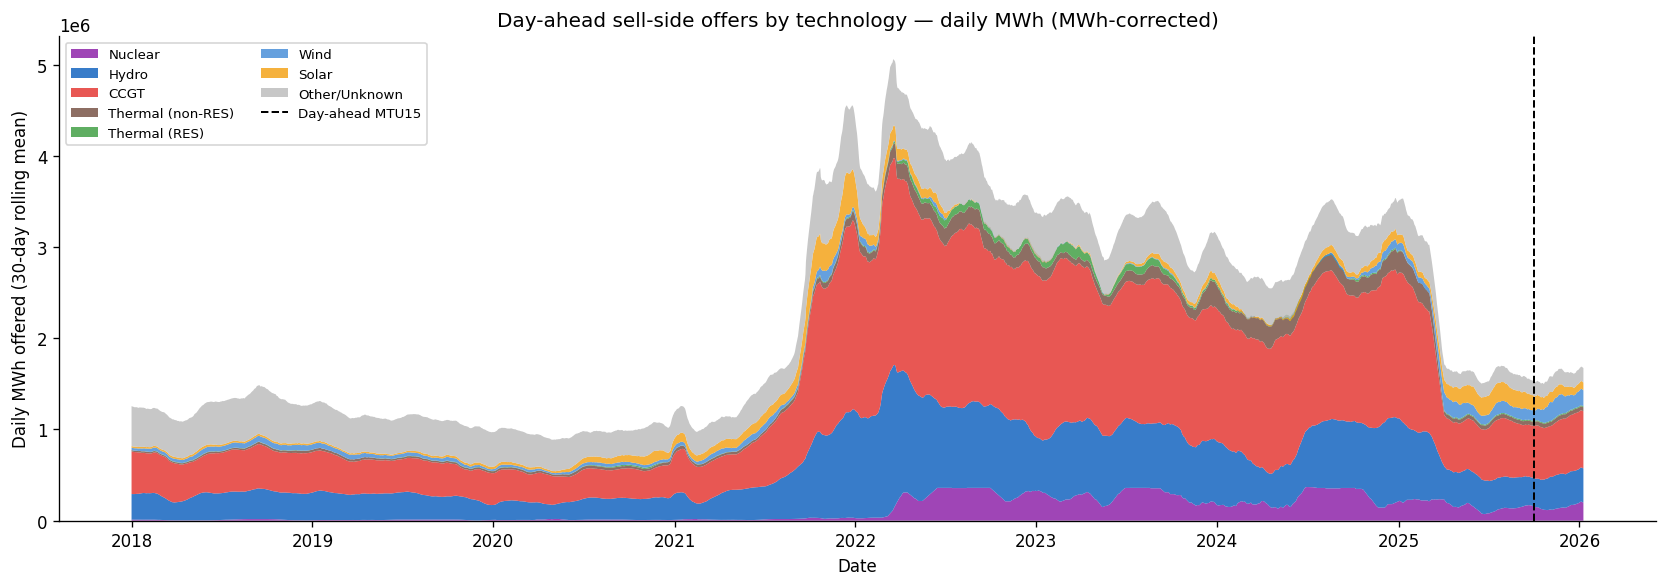

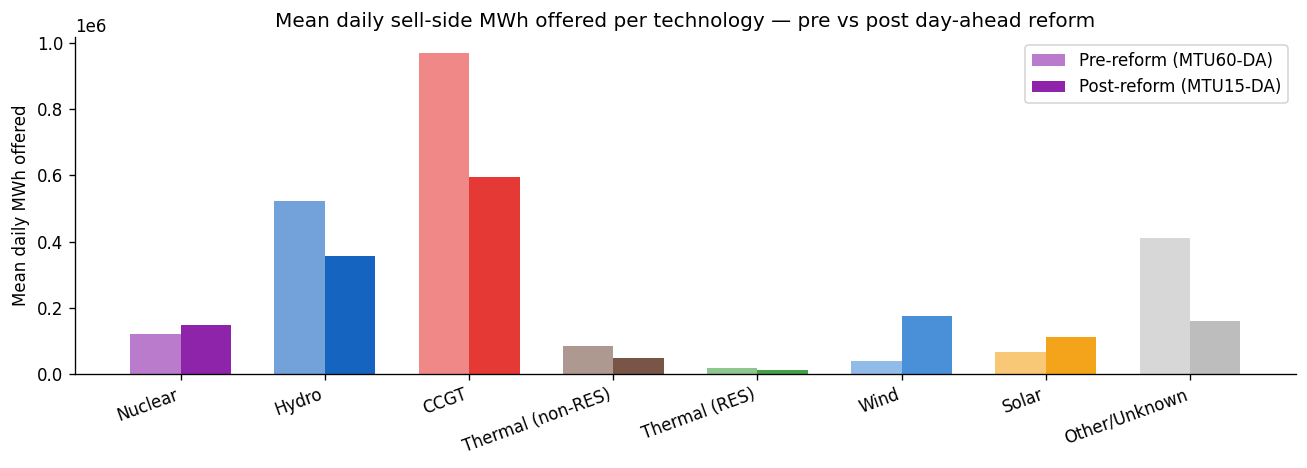

In [27]:
daily_tech = con_det.execute(f"""
    WITH base AS (
        SELECT d.date, d.quantity_mw, d.mtu_minutes, c.unit_code
        FROM read_parquet('{DET}') d
        JOIN read_parquet('{CAB}') c
          ON d.date = c.date AND d.offer_code = c.offer_code
        WHERE c.buy_sell = 'V'
    )
    SELECT b.date,
           CASE
        WHEN u.technology IN ('RE Mercado Solar Fotovoltáica', 'RE Mercado Solar Térmica') THEN 'Solar'
        WHEN u.technology = 'RE Mercado Eólica'                                             THEN 'Wind'
        WHEN u.technology IN ('RE Mercado Hidráulica', 'Hidráulica Generación')             THEN 'Hydro'
        WHEN u.technology = 'Ciclo Combinado'                                               THEN 'CCGT'
        WHEN u.technology = 'Nuclear'                                                       THEN 'Nuclear'
        WHEN u.technology = 'RE Mercado Térmica no Renovab.'                               THEN 'Thermal (non-RES)'
        WHEN u.technology = 'RE Mercado Térmica Renovable'                                 THEN 'Thermal (RES)'
        ELSE 'Other/Unknown'
    END AS tech_group,
           SUM(b.quantity_mw * b.mtu_minutes / 60.0) AS mwh
    FROM base b
    LEFT JOIN read_csv('{UNITS}') u ON b.unit_code = u.unit_code
    GROUP BY b.date, tech_group
    ORDER BY b.date, tech_group
""").df()

daily_tech["date"] = pd.to_datetime(daily_tech["date"])

# Pivot and smooth for stacked area chart
pivot = daily_tech.pivot_table(index="date", columns="tech_group", values="mwh", aggfunc="sum").fillna(0)
pivot = pivot[[c for c in TECH_ORDER if c in pivot.columns]]
pivot_smooth = pivot.rolling(30, center=True, min_periods=7).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(
    pivot_smooth.index,
    [pivot_smooth[c] for c in pivot_smooth.columns],
    labels=pivot_smooth.columns,
    colors=[TECH_COLORS[c] for c in pivot_smooth.columns],
    alpha=0.85,
)
ax.axvline(DAY_AHEAD_REFORM, color="black", linestyle="--", linewidth=1.2, label="Day-ahead MTU15")
ax.set_xlabel("Date")
ax.set_ylabel("Daily MWh offered (30-day rolling mean)")
ax.set_title("Day-ahead sell-side offers by technology — daily MWh (MWh-corrected)")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# Pre / post bar comparison (mean daily MWh per technology)
pre  = daily_tech[daily_tech["date"] <  DAY_AHEAD_REFORM].groupby("tech_group")["mwh"].mean()
post = daily_tech[daily_tech["date"] >= DAY_AHEAD_REFORM].groupby("tech_group")["mwh"].mean()
comp = pd.DataFrame({"Pre-reform (MTU60-DA)": pre, "Post-reform (MTU15-DA)": post}).reindex(TECH_ORDER).dropna(how="all")

fig, ax = plt.subplots(figsize=(11, 4))
x = range(len(comp))
w = 0.35
ax.bar([i - w/2 for i in x], comp["Pre-reform (MTU60-DA)"], width=w, label="Pre-reform (MTU60-DA)",
       color=[TECH_COLORS[t] for t in comp.index], alpha=0.6)
ax.bar([i + w/2 for i in x], comp["Post-reform (MTU15-DA)"], width=w, label="Post-reform (MTU15-DA)",
       color=[TECH_COLORS[t] for t in comp.index], alpha=1.0)
ax.set_xticks(list(x))
ax.set_xticklabels(comp.index, rotation=20, ha="right")
ax.set_ylabel("Mean daily MWh offered")
ax.set_title("Mean daily sell-side MWh offered per technology — pre vs post day-ahead reform")
ax.legend()
plt.tight_layout()
plt.show()


### 7b. Merit order: bid price distribution by technology

**Merit order.** Units are dispatched in increasing order of bid price $s_{i,\pi}$. The P10/P50/P90 of the submitted bid-price distribution for technology group $g$ characterises where each technology sits in the merit order:

$$\tilde{s}^g_\alpha = \hat{F}_g^{-1}(\alpha), \quad \hat{F}_g(p) = \frac{\sum_{i \in g, \pi} q_{i,\pi}\,\mathbf{1}[s_{i,\pi} \leq p]}{\sum_{i \in g, \pi} q_{i,\pi}}$$

**Note on data availability:** The pre-reform DET format (57-char lines, before 2025-03-19) does not contain bid prices — that field is always 0. OMIE started publishing unit-level bid prices with the new 60-char format from **2025-03-19** onward. The analysis covers only 2025-03-19+, split at the day-ahead reform (2025-10-01).


       tech_group                        regime         p10        p50         p90  n_rows
             CCGT Post day-ahead reform (MTU15)   82.776485 116.265556  680.740294 1975480
             CCGT  Pre day-ahead reform (MTU60)   87.396883 125.673064  925.047278  861676
            Hydro Post day-ahead reform (MTU15)  -23.342297   1.497924  370.916260 3214189
            Hydro  Pre day-ahead reform (MTU60)  -22.487428   0.121499  377.410450 1559639
          Nuclear Post day-ahead reform (MTU15) -500.000000 -50.000000 2999.000000  152552
          Nuclear  Pre day-ahead reform (MTU60) -500.000000 -15.000000 2999.000000   80774
    Other/Unknown Post day-ahead reform (MTU15)  -28.745709  -0.000004  178.842677 1735349
    Other/Unknown  Pre day-ahead reform (MTU60)  -31.269546  -0.199728  139.021582 1073877
            Solar Post day-ahead reform (MTU15)  -31.003952 -14.607135    0.757533 4641351
            Solar  Pre day-ahead reform (MTU60)  -44.999730 -10.000060    1.017170 2659503

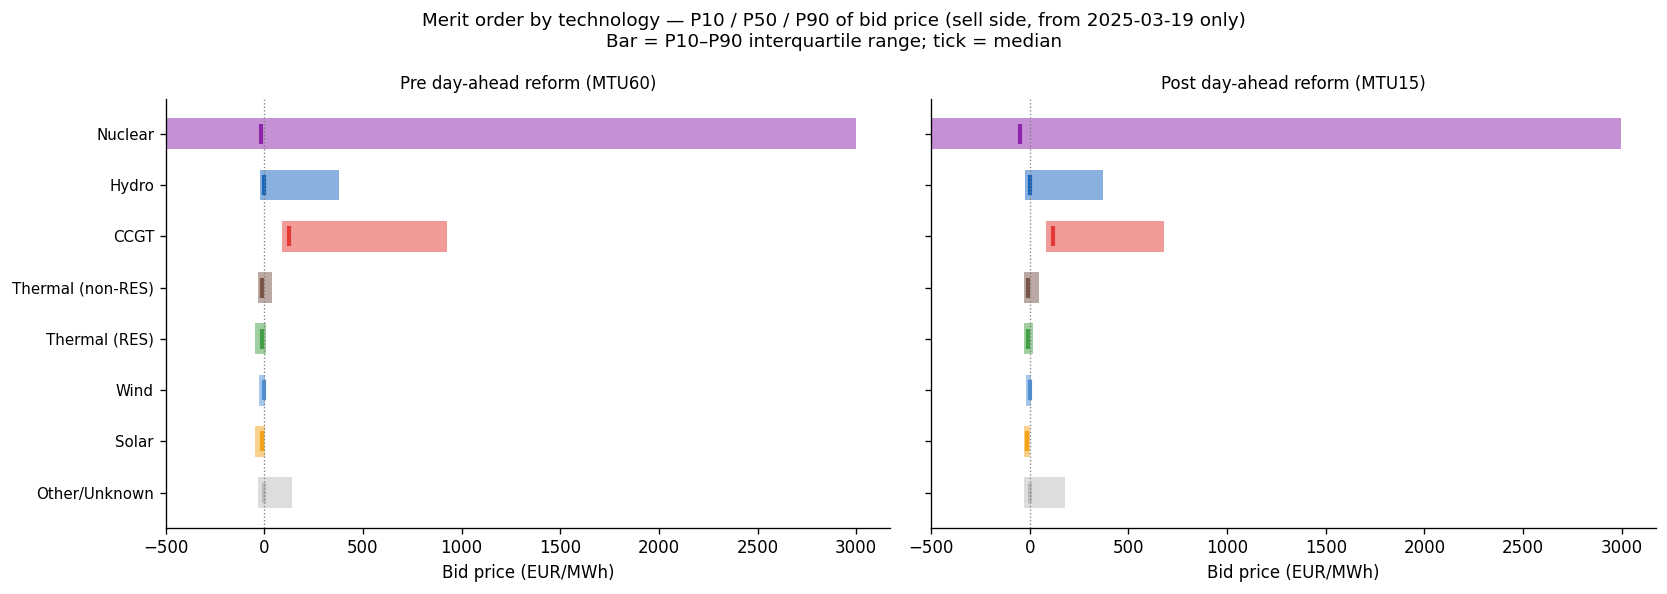

In [28]:
TECH_SQL = """CASE
        WHEN u.technology IN ('RE Mercado Solar Fotovoltáica', 'RE Mercado Solar Térmica') THEN 'Solar'
        WHEN u.technology = 'RE Mercado Eólica'                                             THEN 'Wind'
        WHEN u.technology IN ('RE Mercado Hidráulica', 'Hidráulica Generación')             THEN 'Hydro'
        WHEN u.technology = 'Ciclo Combinado'                                               THEN 'CCGT'
        WHEN u.technology = 'Nuclear'                                                       THEN 'Nuclear'
        WHEN u.technology = 'RE Mercado Térmica no Renovab.'                               THEN 'Thermal (non-RES)'
        WHEN u.technology = 'RE Mercado Térmica Renovable'                                 THEN 'Thermal (RES)'
        ELSE 'Other/Unknown'
    END"""

price_dist = con_det.execute(f"""
    WITH base AS (
        SELECT d.date, d.price_eur_mwh, d.quantity_mw, c.unit_code
        FROM read_parquet('{DET}') d
        JOIN read_parquet('{CAB}') c
          ON d.date = c.date AND d.offer_code = c.offer_code
        -- Only use data where OMIE publishes bid prices (new format from 2025-03-19)
        WHERE d.date >= '2025-03-19'
          AND c.buy_sell = 'V'
    )
    SELECT {TECH_SQL}                                              AS tech_group,
           CASE WHEN b.date < '{DAY_AHEAD_REFORM.date()}'
                THEN 'Pre day-ahead reform (MTU60)'
                ELSE 'Post day-ahead reform (MTU15)' END          AS regime,
           APPROX_QUANTILE(b.price_eur_mwh, 0.10)                AS p10,
           APPROX_QUANTILE(b.price_eur_mwh, 0.50)                AS p50,
           APPROX_QUANTILE(b.price_eur_mwh, 0.90)                AS p90,
           COUNT(*)                                               AS n_rows
    FROM base b
    LEFT JOIN read_csv('{UNITS}') u ON b.unit_code = u.unit_code
    GROUP BY tech_group, regime
    ORDER BY tech_group, regime
""").df()

print(price_dist.to_string(index=False))

regimes  = ["Pre day-ahead reform (MTU60)", "Post day-ahead reform (MTU15)"]
techs    = [t for t in TECH_ORDER if t in price_dist["tech_group"].values]
n_tech   = len(techs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for col_i, regime in enumerate(regimes):
    ax  = axes[col_i]
    sub = price_dist[price_dist["regime"] == regime].set_index("tech_group")
    for i, tech in enumerate(reversed(techs)):
        if tech not in sub.index:
            continue
        row   = sub.loc[tech]
        color = TECH_COLORS[tech]
        ax.barh(i, row["p90"] - row["p10"], left=row["p10"],
                height=0.6, color=color, alpha=0.5)
        ax.plot(row["p50"], i, marker="|", color=color, markersize=12, markeredgewidth=2.5)
    ax.set_yticks(list(range(n_tech)))
    ax.set_yticklabels(list(reversed(techs)), fontsize=9)
    ax.set_xlabel("Bid price (EUR/MWh)")
    ax.set_title(regime, fontsize=10)
    ax.axvline(0, color="grey", linewidth=0.8, linestyle=":")

fig.suptitle(
    "Merit order by technology — P10 / P50 / P90 of bid price (sell side, from 2025-03-19 only)\n"
    "Bar = P10–P90 interquartile range; tick = median",
    fontsize=11
)
plt.tight_layout()
plt.show()


### 7c. Within-day bid price variability by technology

**Does the reform enable finer intraday price differentiation?**

For each sell-side offer on a given day, compute the quantity-weighted average bid price per period, then the standard deviation across periods:

$$\sigma^{\text{bid}}_{i,d} = \operatorname{std}_{\pi}\!\left(\frac{\sum_k s_{i,\pi,k}\,q_{i,\pi,k}}{\sum_k q_{i,\pi,k}}\right)$$

A large $\sigma^{\text{bid}}$ indicates the unit prices very differently at different hours (or quarter-hours). Under MTU15-DA, units can express finer intraday price variation — we expect $\sigma^{\text{bid}}$ to rise for flexible technologies (CCGT, Hydro) and remain near zero for must-run generators (Nuclear, Solar when subsidised).

Uses 2025-03-19+ only (when bid prices became available).


Within-day bid price variability by technology and regime:
       tech_group                        regime   mean_std   median_std  n_obs
             CCGT Post day-ahead reform (MTU15) 164.497436 1.079067e+02   4743
             CCGT  Pre day-ahead reform (MTU60) 189.710305 1.507058e+02   8894
            Hydro Post day-ahead reform (MTU15)   2.635822 0.000000e+00  18690
            Hydro  Pre day-ahead reform (MTU60)   3.015693 0.000000e+00  35954
          Nuclear Post day-ahead reform (MTU15)  21.097112 2.882463e-15   1364
          Nuclear  Pre day-ahead reform (MTU60)  38.303596 0.000000e+00   2565
    Other/Unknown Post day-ahead reform (MTU15)   2.617689 0.000000e+00  19699
    Other/Unknown  Pre day-ahead reform (MTU60)   2.666192 1.046239e-20  46498
            Solar Post day-ahead reform (MTU15)   1.208252 0.000000e+00 107558
            Solar  Pre day-ahead reform (MTU60)   1.403616 0.000000e+00 181842
    Thermal (RES) Post day-ahead reform (MTU15)   0.200578 0.000000e+00 

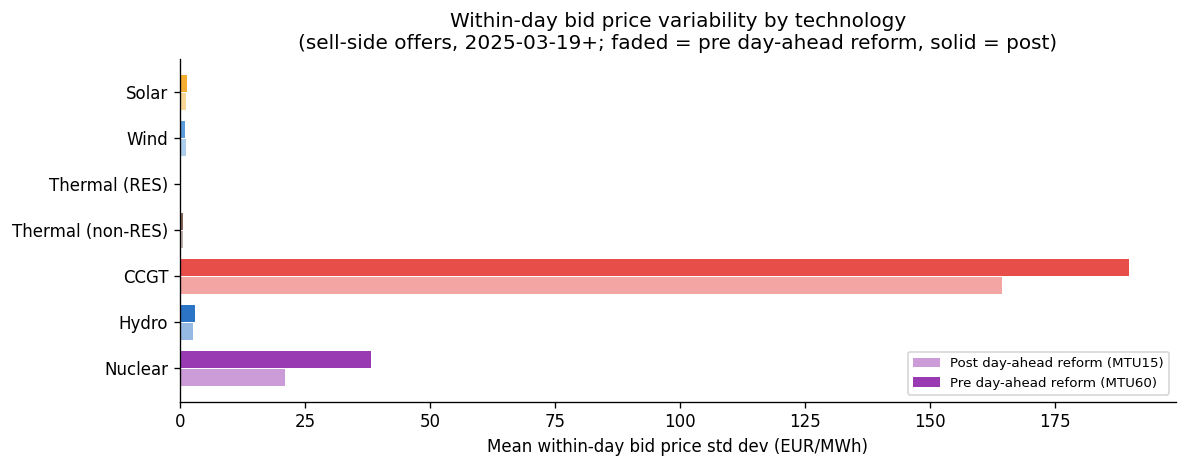

In [29]:
intra_day_std = con_det.execute(f"""
    WITH period_price AS (
        -- Quantity-weighted mean price per (date, offer_code, period)
        SELECT d.date, d.offer_code, d.period, c.unit_code,
               SUM(d.price_eur_mwh * ABS(d.quantity_mw))
                   / NULLIF(SUM(ABS(d.quantity_mw)), 0) AS wavg_price,
               CASE
                   WHEN d.date < '{DAY_AHEAD_REFORM.date()}'
                   THEN 'Pre day-ahead reform (MTU60)'
                   ELSE 'Post day-ahead reform (MTU15)'
               END AS regime
        FROM read_parquet('{DET}') d
        JOIN read_parquet('{CAB}') c
          ON d.date = c.date AND d.offer_code = c.offer_code
        WHERE d.date >= '2025-03-19'
          AND c.buy_sell = 'V'
        GROUP BY d.date, d.offer_code, d.period, c.unit_code, regime
    ),
    daily_std AS (
        SELECT date, offer_code, unit_code, regime,
               STDDEV(wavg_price) AS price_std
        FROM period_price
        GROUP BY date, offer_code, unit_code, regime
        HAVING COUNT(*) >= 4
    )
    SELECT {TECH_SQL} AS tech_group,
           regime,
           AVG(s.price_std)                   AS mean_std,
           APPROX_QUANTILE(s.price_std, 0.50) AS median_std,
           COUNT(*)                           AS n_obs
    FROM daily_std s
    LEFT JOIN read_csv('{UNITS}') u ON s.unit_code = u.unit_code
    GROUP BY tech_group, regime
    ORDER BY tech_group, regime
""").df()

print('Within-day bid price variability by technology and regime:')
print(intra_day_std.to_string(index=False))
print()

main_techs = [t for t in TECH_ORDER if t != 'Other/Unknown']
regimes_avail = sorted(intra_day_std['regime'].unique())
n_reg = len(regimes_avail)
width = 0.8 / max(n_reg, 1)
alpha_levels = [0.45, 0.9]  # faded=pre, solid=post

fig, ax = plt.subplots(figsize=(10, 4))
for i, regime in enumerate(regimes_avail):
    rdf = (
        intra_day_std[intra_day_std['regime'] == regime]
        .set_index('tech_group')
        .reindex(main_techs)
    )
    offset = (i - (n_reg - 1) / 2) * width
    ax.barh(
        [j + offset for j in range(len(main_techs))],
        rdf['mean_std'].fillna(0),
        height=width * 0.92,
        color=[TECH_COLORS[t] for t in main_techs],
        alpha=alpha_levels[i] if i < len(alpha_levels) else 0.7,
        label=regime,
    )

ax.set_yticks(range(len(main_techs)))
ax.set_yticklabels(main_techs)
ax.set_xlabel('Mean within-day bid price std dev (EUR/MWh)')
ax.set_title(
    'Within-day bid price variability by technology\n'
    '(sell-side offers, 2025-03-19+; faded = pre day-ahead reform, solid = post)'
)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


### 7d. Intraday offer profile by technology and hour of day

**Technology-hour offer profile.** Mean quantity offered (MW) per technology and hour, averaged across days in each regime:

$$\bar{q}^g_h = \frac{1}{|T_r|} \sum_{d \in T_r} \sum_{\pi : h(\pi)=h} \sum_{i \in g} q_{i,\pi,d}$$

Both MTU60-DA and MTU15-DA data are mapped to hours 1–24. The stacked view reveals how the technology mix shapes the supply curve at each hour of day, and whether this shape changed after the reform.


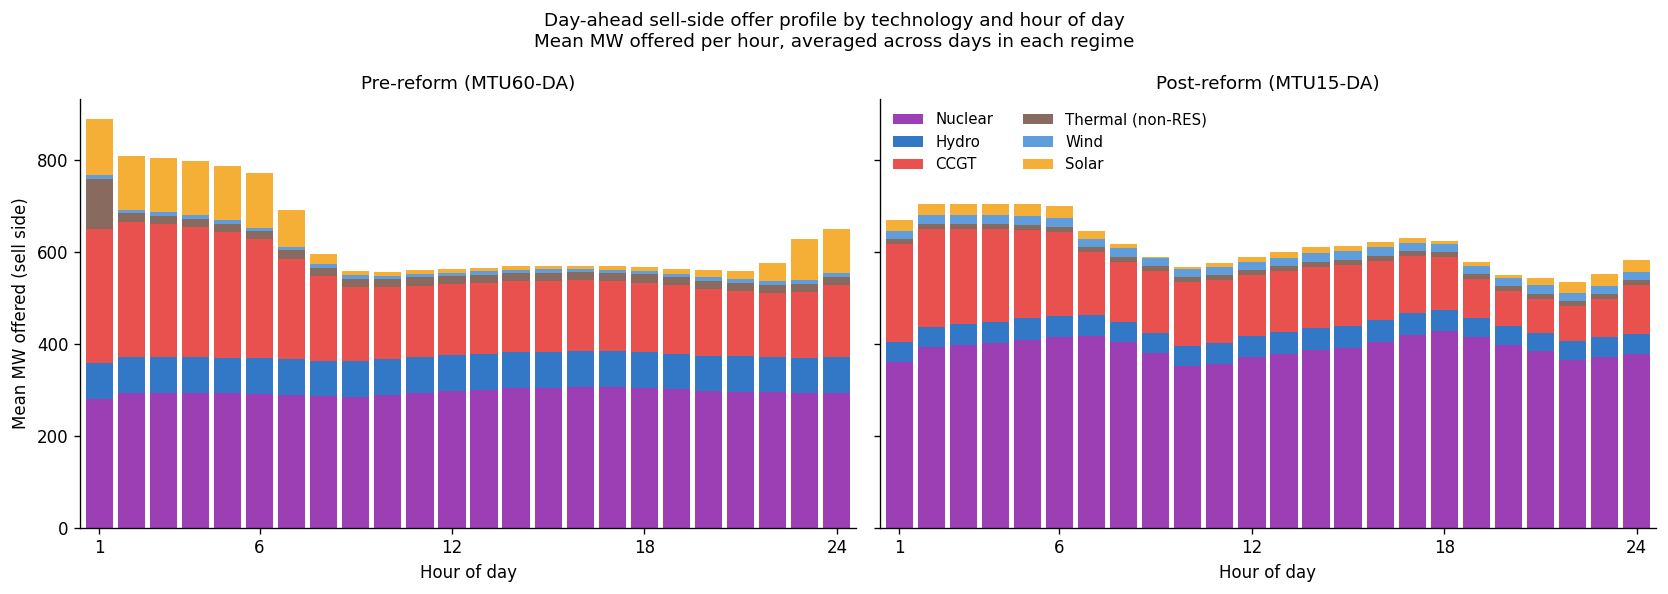

Technology            Pre peak hour  Post peak hour
---------------------------------------------------
Nuclear                          16              18
Hydro                            16              15
CCGT                              2               1
Thermal (non-RES)                 1               4
Wind                              1              15
Solar                             1               6


In [30]:
profile = con_det.execute(f"""
    WITH base AS (
        SELECT d.date, d.quantity_mw, d.mtu_minutes,
               CASE WHEN d.mtu_minutes = 60 THEN CAST(d.period AS INT)
                    ELSE (CAST(d.period AS INT) - 1) / 4 + 1
               END AS hour_of_day,
               c.unit_code
        FROM read_parquet('{DET}') d
        JOIN read_parquet('{CAB}') c
          ON d.date = c.date AND d.offer_code = c.offer_code
        WHERE c.buy_sell = 'V'
    )
    SELECT CASE
        WHEN u.technology IN ('RE Mercado Solar Fotovoltáica', 'RE Mercado Solar Térmica') THEN 'Solar'
        WHEN u.technology = 'RE Mercado Eólica'                                             THEN 'Wind'
        WHEN u.technology IN ('RE Mercado Hidráulica', 'Hidráulica Generación')             THEN 'Hydro'
        WHEN u.technology = 'Ciclo Combinado'                                               THEN 'CCGT'
        WHEN u.technology = 'Nuclear'                                                       THEN 'Nuclear'
        WHEN u.technology = 'RE Mercado Térmica no Renovab.'                               THEN 'Thermal (non-RES)'
        WHEN u.technology = 'RE Mercado Térmica Renovable'                                 THEN 'Thermal (RES)'
        ELSE 'Other/Unknown'
    END                  AS tech_group,
           CASE WHEN b.date < '{DAY_AHEAD_REFORM.date()}' THEN 'Pre-reform (MTU60-DA)'
                ELSE 'Post-reform (MTU15-DA)' END AS regime,
           hour_of_day,
           AVG(b.quantity_mw)          AS mean_mw
    FROM base b
    LEFT JOIN read_csv('{UNITS}') u ON b.unit_code = u.unit_code
    WHERE hour_of_day BETWEEN 1 AND 24
    GROUP BY tech_group, regime, hour_of_day
    ORDER BY tech_group, regime, hour_of_day
""").df()

focus_techs = ['Nuclear', 'Hydro', 'CCGT', 'Thermal (non-RES)', 'Wind', 'Solar']
regimes     = ["Pre-reform (MTU60-DA)", "Post-reform (MTU15-DA)"]

def regime_pivot(df, regime):
    sub = df[df["regime"] == regime]
    piv = sub.pivot_table(index="hour_of_day", columns="tech_group", values="mean_mw", aggfunc="mean").fillna(0)
    return piv[[c for c in focus_techs if c in piv.columns]]

pre_piv  = regime_pivot(profile, "Pre-reform (MTU60-DA)")
post_piv = regime_pivot(profile, "Post-reform (MTU15-DA)")

hours = list(range(1, 25))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, piv, title_str in [
    (axes[0], pre_piv,  "Pre-reform (MTU60-DA)"),
    (axes[1], post_piv, "Post-reform (MTU15-DA)"),
]:
    bottom = [0] * 24
    for tech in [c for c in focus_techs if c in piv.columns]:
        vals = [piv.loc[h, tech] if h in piv.index else 0 for h in hours]
        ax.bar(hours, vals, bottom=bottom,
               color=TECH_COLORS[tech], alpha=0.88, width=0.85, label=tech)
        bottom = [b + v for b, v in zip(bottom, vals)]
    ax.set_xlim(0.4, 24.6)
    ax.set_xticks([1, 6, 12, 18, 24])
    ax.set_xlabel("Hour of day")
    ax.set_title(title_str, fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Mean MW offered (sell side)")
axes[1].legend(loc="upper left", fontsize=9, ncol=2, framealpha=0.85, edgecolor="none")
fig.suptitle(
    "Day-ahead sell-side offer profile by technology and hour of day\n"
    "Mean MW offered per hour, averaged across days in each regime",
    fontsize=11,
)
plt.tight_layout()
plt.show()

print(f"{'Technology':<20} {'Pre peak hour':>14} {'Post peak hour':>15}")
print("-" * 51)
for tech in focus_techs:
    pre_h  = int(pre_piv[tech].idxmax())  if tech in pre_piv.columns  and pre_piv[tech].max()  > 0 else "n/a"
    post_h = int(post_piv[tech].idxmax()) if tech in post_piv.columns and post_piv[tech].max() > 0 else "n/a"
    print(f"{tech:<20} {str(pre_h):>14} {str(post_h):>15}")


---
## Section 8 — Continuous intraday order book (`orders`)

Data: `orders_all.parquet` — individual limit orders submitted to the XBID cross-border continuous intraday market (§5.3.3.1 of OMIE spec). One row per order submitted.

**Object definition.** A limit order is a tuple

$$o = \bigl(\alpha_o,\; \bar{p}_o,\; \bar{q}_o,\; \kappa_o,\; \tau_o^{\text{sub}},\; w_o\bigr)$$

where $\alpha_o \in \{\text{buy},\text{sell}\}$ is the side, $\bar{p}_o$ (EUR/MWh) is the limit price, $\bar{q}_o$ (MW) is the limit quantity, $\kappa_o$ is the execution condition (GFD = Good-for-Day, IOC = Immediate-or-Cancel, AON = All-or-Nothing, …), $\tau_o^{\text{sub}}$ is the submission timestamp, and $w_o$ is the target delivery window (date × period).

The submitted energy is $\bar{E}_o = \bar{q}_o \cdot \delta_w / 60$, where $\delta_w = 60$ min pre-2025-03-19 and $\delta_w = 15$ min post-reform.

> **Observability caveat.** The `orders` table records *submitted* orders only — subsequent cancellations and partial fills are not observable. We therefore characterise the *submitted* price–quantity distribution, which is an upper bound on the true resting order book.

OMIE applies a **90-day confidentiality window**: months within 90 days of today return HTTP 404, so coverage ends approximately three months before the current date.


In [31]:
ORDERS = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_continuo/ofertas/orders_all.parquet"
con_ord = duckdb.connect()

info = con_ord.execute(f"""
    SELECT
        COUNT(*)                                       AS total_rows,
        COUNT(DISTINCT source_file)                    AS n_files,
        COUNT(DISTINCT trade_date)                     AS n_days,
        MIN(trade_date)                                AS date_min,
        MAX(trade_date)                                AS date_max,
        COUNT(DISTINCT zone)                           AS n_zones,
        COUNT(DISTINCT agent)                          AS n_agents,
        COUNT(DISTINCT unit_code)                      AS n_units
    FROM read_parquet('{ORDERS}')
""").fetchone()

print(f"Total rows:   {info[0]:>15,}")
print(f"Files:        {info[1]:>15,}")
print(f"Days:         {info[2]:>15,}")
print(f"Date range:   {info[3]} -> {info[4]}")
print(f"Zones:        {info[5]:>15,}")
print(f"Agents:       {info[6]:>15,}")
print(f"Units:        {info[7]:>15,}")

mtu_dist = con_ord.execute(f"""
    SELECT mtu_minutes, COUNT(DISTINCT trade_date) AS n_days
    FROM read_parquet('{ORDERS}')
    GROUP BY mtu_minutes ORDER BY mtu_minutes
""").df()
print(f"\nDays by MTU:")
print(mtu_dist.to_string(index=False))


Total rows:       160,184,746
Files:                  2,771
Days:                   2,771
Date range:   2018-06-13 -> 2026-01-13
Zones:                      2
Agents:                   326
Units:                  2,951

Days by MTU:
 mtu_minutes  n_days
          15     301
          60    2471


### 8a. Limit-price distribution by side and regime

For each side $\alpha \in \{\text{buy},\text{sell}\}$ and regime, we estimate the submitted price CDF:

$$\hat{F}_\alpha(p) = \frac{1}{|\mathcal{O}_\alpha|} \sum_{o \in \mathcal{O}_\alpha} \mathbf{1}[\bar{p}_o \leq p]$$

P10/P25/P50/P75/P90 are reported by side and MTU regime. A well-functioning book should have sell P50 $>$ buy P50 (limit prices are not systematically crossed), and both should straddle the observed clearing prices from `precios_pibcic_ronda`.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Submitted limit-price distribution (P10/P25/P50/P75/P90):
offer_type                 regime  n_orders  mean_mw    p10   p25   p50    p75    p90
         C Post-MTU15-IDA (MTU15)  49861849     9.10 -15.16  2.77 47.37  83.16 106.14
         V Post-MTU15-IDA (MTU15)  41211958     9.15   3.93 32.22 76.69 100.25 123.76
         C  Pre-MTU15-IDA (MTU60)  34728537    16.95   5.22 32.27 73.43 117.39 168.05
         V  Pre-MTU15-IDA (MTU60)  34382402    16.36  28.69 53.89 93.26 135.58 202.98


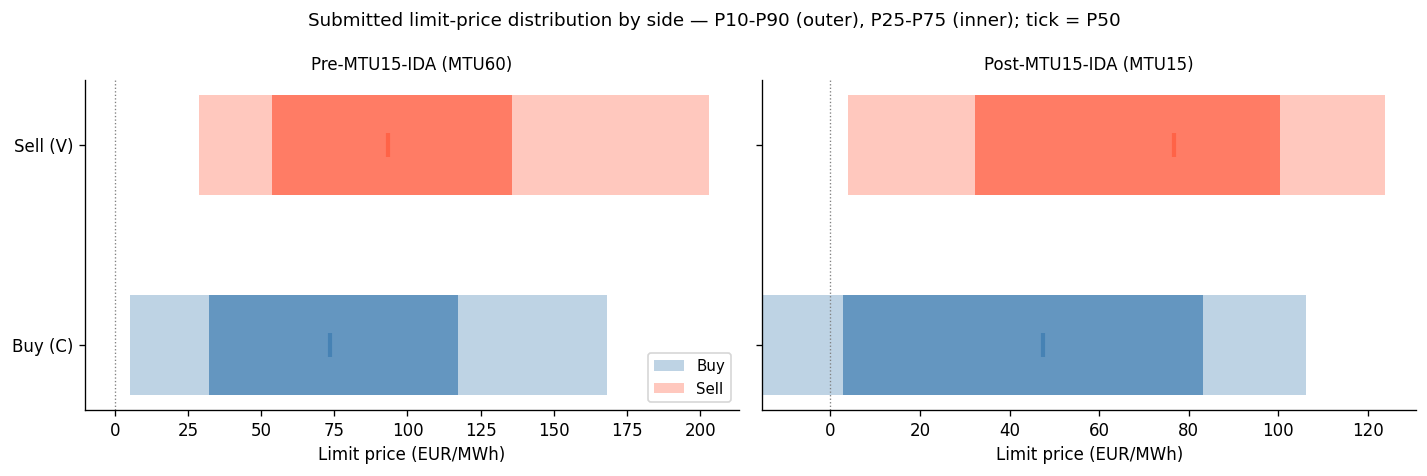

In [32]:
INTRADAY_REFORM_STR = INTRADAY_REFORM.date().isoformat()

price_dist = con_ord.execute(f"""
    SELECT
        offer_type,
        CASE WHEN trade_date < '{INTRADAY_REFORM_STR}' THEN 'Pre-MTU15-IDA (MTU60)'
             ELSE 'Post-MTU15-IDA (MTU15)' END                    AS regime,
        COUNT(*)                                               AS n_orders,
        ROUND(AVG(quantity_mw), 2)                            AS mean_mw,
        ROUND(APPROX_QUANTILE(price_eur_mwh, 0.10), 2)       AS p10,
        ROUND(APPROX_QUANTILE(price_eur_mwh, 0.25), 2)       AS p25,
        ROUND(APPROX_QUANTILE(price_eur_mwh, 0.50), 2)       AS p50,
        ROUND(APPROX_QUANTILE(price_eur_mwh, 0.75), 2)       AS p75,
        ROUND(APPROX_QUANTILE(price_eur_mwh, 0.90), 2)       AS p90
    FROM read_parquet('{ORDERS}')
    GROUP BY offer_type, regime
    ORDER BY regime, offer_type
""").df()

print("Submitted limit-price distribution (P10/P25/P50/P75/P90):")
print(price_dist.to_string(index=False))

# --- Plot: box-plot-style (P10-P90 outer bar, P25-P75 inner bar, P50 tick) ---
regimes_list  = ["Pre-MTU15-IDA (MTU60)", "Post-MTU15-IDA (MTU15)"]
sides         = [("C", "Buy", "steelblue"), ("V", "Sell", "tomato")]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for col_i, (regime, ax) in enumerate(zip(regimes_list, axes)):
    sub = price_dist[price_dist["regime"] == regime]
    for row_i, (side_code, side_label, color) in enumerate(sides):
        row = sub[sub["offer_type"] == side_code]
        if row.empty:
            continue
        row = row.iloc[0]
        ax.barh(row_i, row["p90"] - row["p10"], left=row["p10"],
                height=0.5, color=color, alpha=0.35, label=side_label if col_i == 0 else "")
        ax.barh(row_i, row["p75"] - row["p25"], left=row["p25"],
                height=0.5, color=color, alpha=0.75)
        ax.plot(row["p50"], row_i, marker="|", color=color, markersize=14, markeredgewidth=2.5)

    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Buy (C)", "Sell (V)"])
    ax.set_xlabel("Limit price (EUR/MWh)")
    ax.set_title(regime, fontsize=10)
    ax.axvline(0, color="grey", linewidth=0.8, linestyle=":")

axes[0].legend(fontsize=9, loc="lower right")
fig.suptitle(
    "Submitted limit-price distribution by side — P10-P90 (outer), P25-P75 (inner); tick = P50",
    fontsize=11
)
plt.tight_layout()
plt.show()


### 8b. Execution-condition breakdown over time

OMIE supports several execution conditions $\kappa_o$:
- **GFD** (Good-for-Day): order rests in the book until matched, cancelled, or delivery closes
- **IOC** (Immediate-or-Cancel): executed immediately at the best available price, remainder cancelled
- **AON** (All-or-None): must be fully matched or rejected in full

**Execution-condition share.** The monthly share of condition $\kappa$ among all submitted orders is:

$$\phi_m^\kappa = \frac{\bigl|\{o \in \mathcal{O}_m : \kappa_o = \kappa\}\bigr|}{|\mathcal{O}_m|}$$

where $\mathcal{O}_m$ is the set of orders with submission date in month $m$. The IOC share
$\phi_m^{\text{IOC}}$ is a proxy for *immediacy preference* — participants seeking price
discovery without sustained book exposure. Similarly, $\phi_m^{\text{AON}}$ captures
block-execution demand. A post-reform shift toward IOC would suggest that 15-min delivery
granularity raises execution urgency as participants race to fill smaller delivery windows.


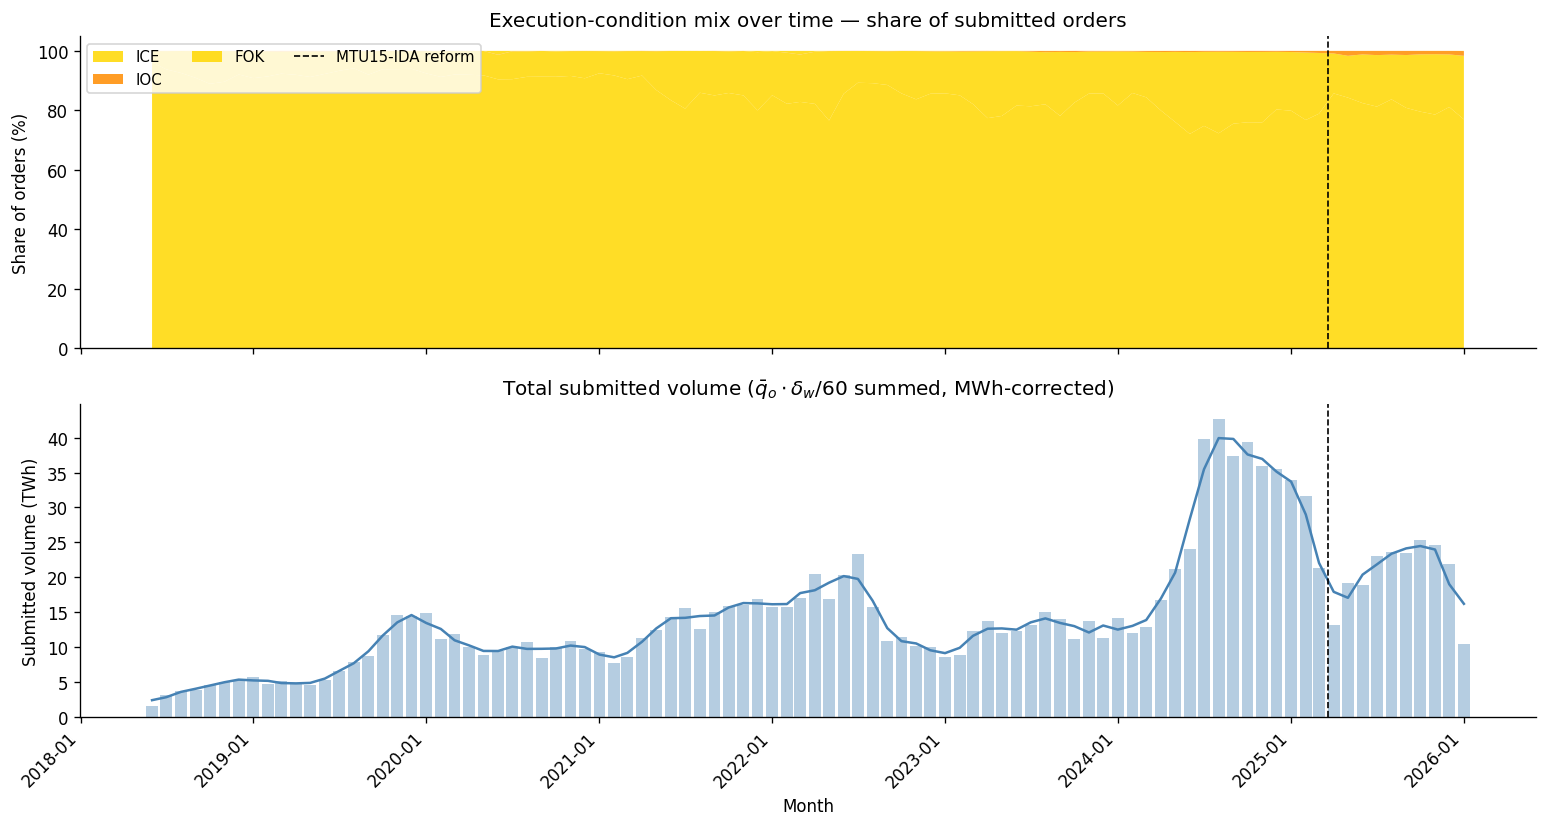

Mean IOC share by regime:
  Pre-MTU15  (<2025-03-19): 0.1%
  Post-MTU15 (>=2025-03-19): 1.3%


In [33]:
exec_monthly = con_ord.execute(f"""
    SELECT
        DATE_TRUNC('month', CAST(trade_date AS DATE))  AS month,
        exec_condition,
        COUNT(*)                                        AS n_orders,
        SUM(quantity_mw * mtu_minutes / 60.0)          AS total_mwh
    FROM read_parquet('{ORDERS}')
    GROUP BY month, exec_condition
    ORDER BY month, exec_condition
""").df()

exec_monthly["month"] = pd.to_datetime(exec_monthly["month"])

# Pivot to share per month
pivot_count = exec_monthly.pivot_table(
    index="month", columns="exec_condition", values="n_orders", aggfunc="sum"
).fillna(0)
pivot_share = pivot_count.div(pivot_count.sum(axis=1), axis=0) * 100

top_conds = pivot_share.sum().nlargest(5).index.tolist()
pivot_share = pivot_share[top_conds]

EXEC_COLORS = {
    "GFD": "steelblue", "IOC": "darkorange", "AON": "seagreen",
    "GTD": "orchid",    "GFS": "crimson",
}

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].stackplot(
    pivot_share.index,
    [pivot_share[c] for c in top_conds],
    labels=top_conds,
    colors=[EXEC_COLORS.get(c, "gold") for c in top_conds],
    alpha=0.85,
)
axes[0].axvline(INTRADAY_REFORM, color="black", linestyle="--", linewidth=1, label="MTU15-IDA reform")
axes[0].set_ylabel("Share of orders (%)")
axes[0].set_title("Execution-condition mix over time — share of submitted orders")
axes[0].legend(loc="upper left", fontsize=9, ncol=3)

monthly_total = exec_monthly.groupby("month")["total_mwh"].sum().reset_index()
monthly_total["smoothed"] = monthly_total["total_mwh"].rolling(3, center=True, min_periods=1).mean()
axes[1].bar(monthly_total["month"], monthly_total["total_mwh"] / 1e6,
            width=25, color="steelblue", alpha=0.4)
axes[1].plot(monthly_total["month"], monthly_total["smoothed"] / 1e6,
             color="steelblue", linewidth=1.5)
axes[1].axvline(INTRADAY_REFORM, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Submitted volume (TWh)")
axes[1].set_title(r"Total submitted volume ($\bar{q}_o \cdot \delta_w / 60$ summed, MWh-corrected)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Mean IOC share by regime:")
for regime_label, mask in [
    ("Pre-MTU15  (<2025-03-19)", pivot_share.index < INTRADAY_REFORM),
    ("Post-MTU15 (>=2025-03-19)", pivot_share.index >= INTRADAY_REFORM),
]:
    sub = pivot_share[mask]
    if "IOC" in sub.columns:
        print(f"  {regime_label}: {sub['IOC'].mean():.1f}%")


### 8c. Submitted prices vs. clearing price — cross-validation

A buy limit order at $\bar{p}_o^{\text{buy}}$ executes only against a sell order at $\bar{p}_o^{\text{sell}} \leq \bar{p}_o^{\text{buy}}$; clearing occurs at the passive (resting) order's price. Therefore:

$$\bar{p}_o^{\text{sell}} \leq p^*_{t,w} \leq \bar{p}_o^{\text{buy}} \quad \text{for each matched pair}$$

In aggregate, submitted sell orders form the ask side: orders at the P10 of the sell distribution are the most aggressively priced sellers. Similarly, buy orders near the P90 of the buy distribution are the most aggressive buyers. A consistency check is:

$$\underbrace{\tilde{p}^{\text{sell}}_{\text{P10}}}_{\text{aggressive ask}} \;\leq\; p^* \;\leq\; \underbrace{\tilde{p}^{\text{buy}}_{\text{P90}}}_{\text{aggressive bid}}$$

This is a weaker condition than full book consistency, but it verifies that the clearing price is reachable by submitted orders on both sides. Note that sell P50 > buy P50 is expected and represents the **book spread**: most submitted orders are not immediately crossing, so they rest in the book waiting for counterparts.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

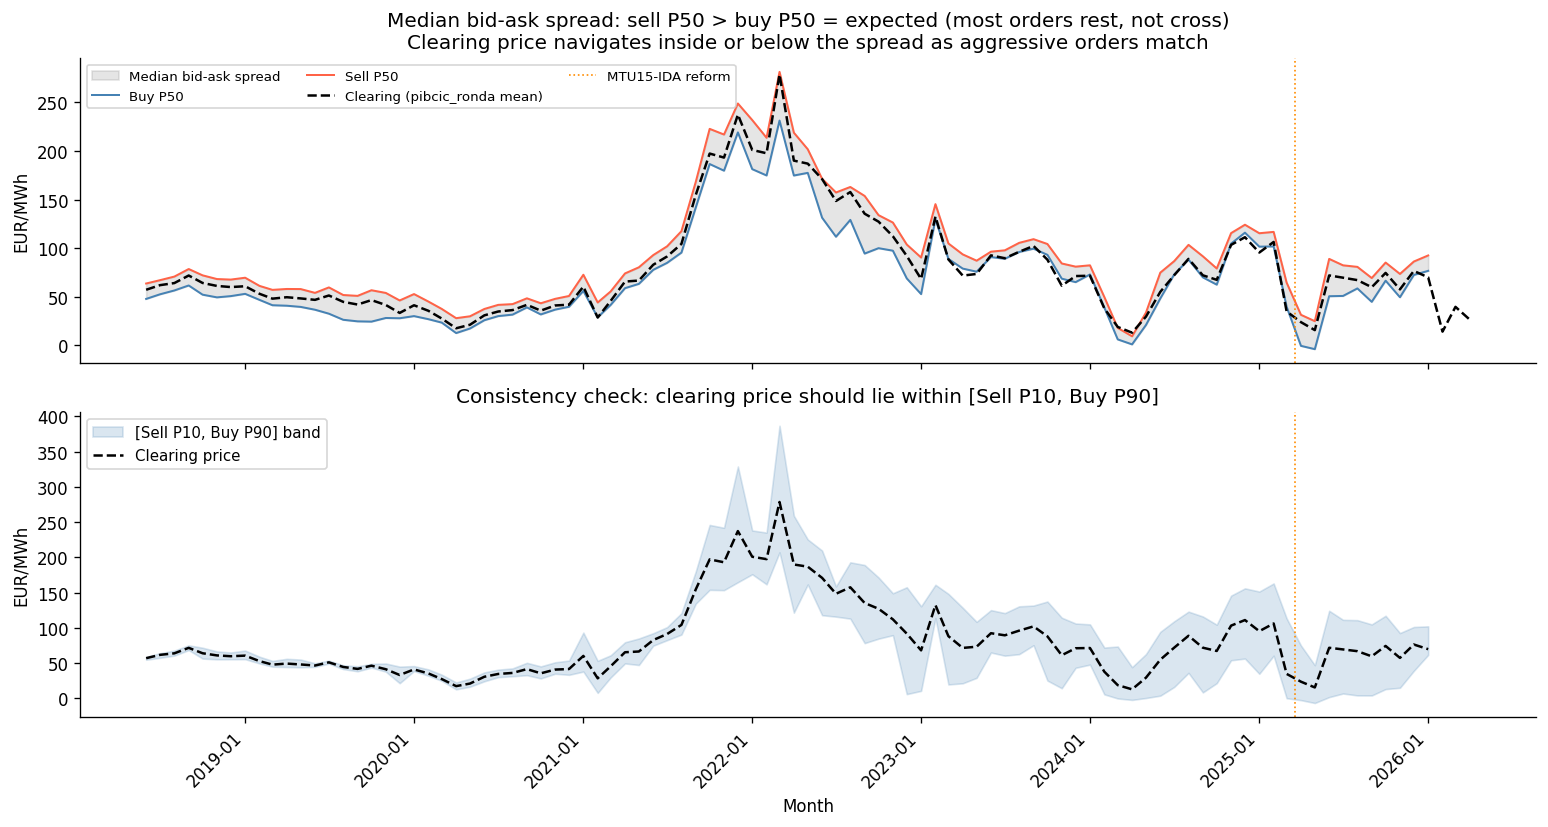

Months where clearing price lies inside [sell P10, buy P90]: 92 / 92
Mean book spread (sell P50 - buy P50): 20.84 EUR/MWh
Mean book spread pre-MTU15-IDA:  20.34 EUR/MWh
Mean book spread post-MTU15-IDA: 24.95 EUR/MWh


In [34]:
# Monthly P10 for sell orders, P90 for buy orders (aggressive side of each)
ord_monthly2 = con_ord.execute(f"""
    SELECT
        DATE_TRUNC('month', CAST(trade_date AS DATE))  AS month,
        offer_type,
        APPROX_QUANTILE(price_eur_mwh, 0.10)           AS p10,
        APPROX_QUANTILE(price_eur_mwh, 0.50)           AS p50,
        APPROX_QUANTILE(price_eur_mwh, 0.90)           AS p90
    FROM read_parquet('{ORDERS}')
    GROUP BY month, offer_type
    ORDER BY month, offer_type
""").df()
ord_monthly2["month"] = pd.to_datetime(ord_monthly2["month"])

buy_p50  = ord_monthly2[ord_monthly2["offer_type"] == "C"].set_index("month")["p50"]
buy_p90  = ord_monthly2[ord_monthly2["offer_type"] == "C"].set_index("month")["p90"]
sell_p50 = ord_monthly2[ord_monthly2["offer_type"] == "V"].set_index("month")["p50"]
sell_p10 = ord_monthly2[ord_monthly2["offer_type"] == "V"].set_index("month")["p10"]

# Clearing price from precios_pibcic_ronda (already loaded)
clearing_monthly = (
    period_price.groupby(period_price["date"].dt.to_period("M"))["price_mean_es_eur_mwh"]
    .mean()
    .reset_index()
)
clearing_monthly["month"] = clearing_monthly["date"].dt.to_timestamp()
clearing_monthly = clearing_monthly.set_index("month")["price_mean_es_eur_mwh"]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Top: bid-ask spread at the median level (sell P50 - buy P50)
common = sell_p50.index.intersection(buy_p50.index)
spread = sell_p50[common] - buy_p50[common]
axes[0].fill_between(common, buy_p50[common], sell_p50[common],
                     alpha=0.2, color="gray", label="Median bid-ask spread")
axes[0].plot(buy_p50.index,  buy_p50.values,  color="steelblue", linewidth=1.2, label="Buy P50")
axes[0].plot(sell_p50.index, sell_p50.values, color="tomato",    linewidth=1.2, label="Sell P50")
axes[0].plot(clearing_monthly.index, clearing_monthly.values,
             color="black", linewidth=1.5, linestyle="--", label="Clearing (pibcic_ronda mean)")
axes[0].axvline(INTRADAY_REFORM, color="darkorange", linestyle=":", linewidth=1, label="MTU15-IDA reform")
axes[0].set_ylabel("EUR/MWh")
axes[0].set_title(
    "Median bid-ask spread: sell P50 > buy P50 = expected (most orders rest, not cross)\n"
    "Clearing price navigates inside or below the spread as aggressive orders match"
)
axes[0].legend(fontsize=8, ncol=3)

# Bottom: consistency check — clearing in [sell P10, buy P90]
common2 = sell_p10.index.intersection(buy_p90.index).intersection(clearing_monthly.index)
axes[1].fill_between(common2, sell_p10[common2], buy_p90[common2],
                     alpha=0.2, color="steelblue", label="[Sell P10, Buy P90] band")
axes[1].plot(clearing_monthly[common2].index, clearing_monthly[common2].values,
             color="black", linewidth=1.5, linestyle="--", label="Clearing price")
axes[1].axvline(INTRADAY_REFORM, color="darkorange", linestyle=":", linewidth=1)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("EUR/MWh")
axes[1].set_title("Consistency check: clearing price should lie within [Sell P10, Buy P90]")
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

n_inside = (
    (clearing_monthly[common2] >= sell_p10[common2]) &
    (clearing_monthly[common2] <= buy_p90[common2])
).sum()
print(f"Months where clearing price lies inside [sell P10, buy P90]: {n_inside} / {len(common2)}")
print(f"Mean book spread (sell P50 - buy P50): {spread.mean():.2f} EUR/MWh")
print(f"Mean book spread pre-MTU15-IDA:  {spread[spread.index < INTRADAY_REFORM].mean():.2f} EUR/MWh")
print(f"Mean book spread post-MTU15-IDA: {spread[spread.index >= INTRADAY_REFORM].mean():.2f} EUR/MWh")


---
## Section 9 — Interconnection capacity (`capacidad_inter_pbc` + `capacidad_inter_pvp`)

Data: two companion families, published daily, **2023-01-01 → 2026-04-14**:

- **`capacidad_inter_pbc`**: capacities declared *after* the day-ahead (PBC) clearing — net transfer
  capacities made available once cross-border trade is scheduled.
- **`capacidad_inter_pvp`**: capacities remaining *after* technical restriction procedures (PVP) — the
  physically available margin once voltage, stability, and network constraints are enforced.

**Capacity decomposition.** For border $b \in \{\text{PT}=2, \text{FR}=3, \text{MA}=4, \text{AND}=5\}$,
delivery period $\pi$, and direction $d \in \{\text{import}, \text{export}\}$, OMIE publishes:

$$F^d_{b,\pi} = C^d_{b,\pi} - \Gamma^d_{b,\pi} \geq 0$$

where $C^d_{b,\pi}$ (MW) is the declared total capacity, $\Gamma^d_{b,\pi}$ is the occupied
(scheduled) capacity, and $F^d_{b,\pi}$ is the free (unscheduled) residual. When
$F^d_{b,\pi} = 0$ the interconnection is **binding**: the two zones decouple and
$p^*_{\text{ES},\pi} \neq p^*_{\text{FR/PT/MA},\pi}$.

**Congestion indicator.** Define the period-level congestion indicator:

$$\rho^d_{b,\pi} = \mathbf{1}\bigl[F^d_{b,\pi} \leq 0\bigr]$$

The daily congestion rate for border $b$ in direction $d$ is $\bar{\rho}^d_b = \frac{1}{|\Pi|}\sum_\pi \rho^d_{b,\pi}$.
When capacity $F^d_{b,\pi}$ is positive but small, zonal prices can still diverge
intra-day even if the constraint is not fully binding on average.

**MTU15 day-ahead reform.** From 2025-10-01, both families expand from 24 to 96 delivery periods per day,
enabling finer tracking of intraday constraint patterns. The PBC–PVP gap $C^d_{b,\pi} - F^{d,\text{pvp}}_{b,\pi}$
measures the capacity absorbed by technical restrictions.

**Coverage:** 1,200 files (PBC) / 1,199 files (PVP) · MTU60: 1,003 days; MTU15-DA: 197 days.


,file_family,n_days,date_min,date_max,mtu15_days,mtu60_days
0,pbc,1200,2023-01-01,2026-04-14,197,1003
1,pvp,1199,2023-01-01,2026-04-14,193,1006


Congestion rates (F <= 0) by border and MTU regime (PVP):


,border_name,mtu_minutes,import_congestion_rate,export_congestion_rate,n_obs
0,AND,15,1.0,0.0110,18528
1,AND,60,1.0,0.0046,24143
2,FR,15,1.0,0.3684,18528
3,FR,60,1.0,0.3293,24143
4,MA,15,1.0,0.0155,18528
5,MA,60,1.0,0.0016,24143
6,PT,15,1.0,0.0596,18528
7,PT,60,1.0,0.0686,24143


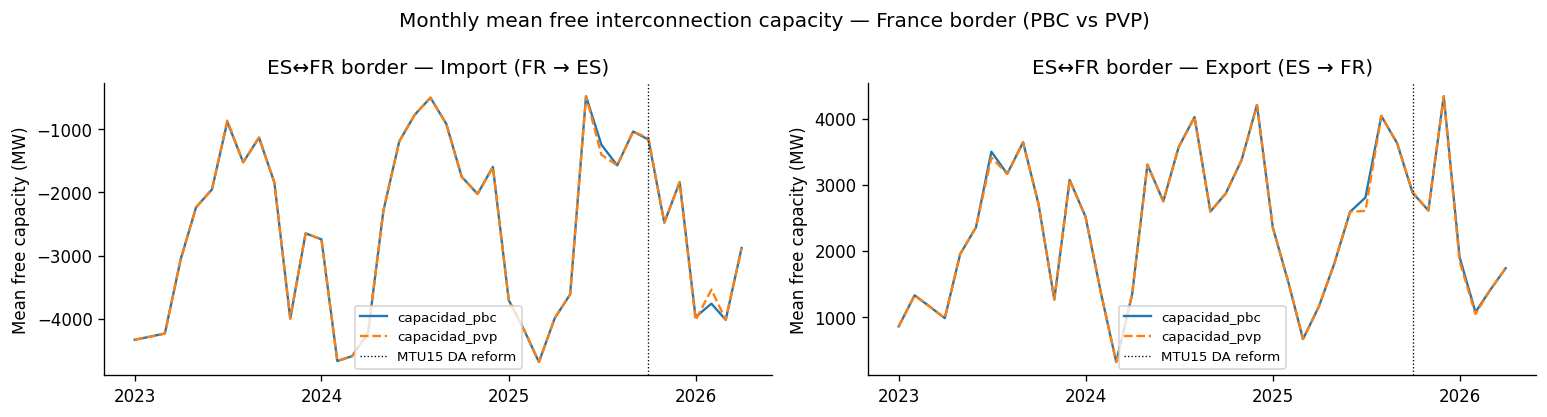

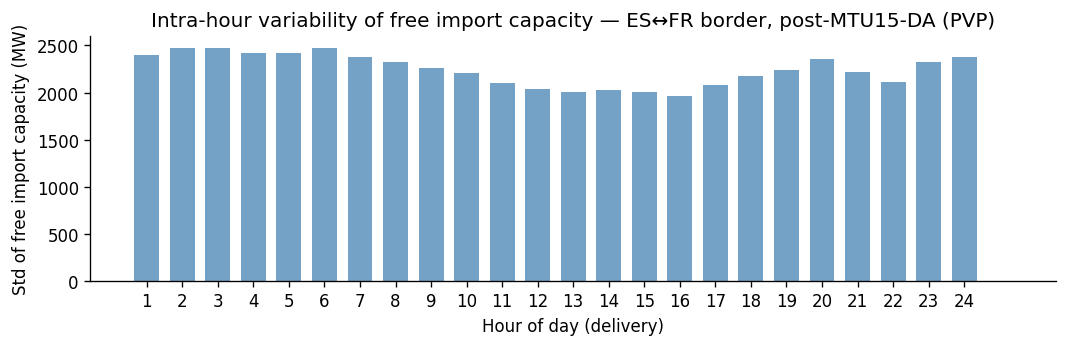

In [35]:
con_cap = duckdb.connect()
cap_pbc = str(CAPACIDAD_INTER_PBC)
cap_pvp = str(CAPACIDAD_INTER_PVP)

# ── 9a. Coverage and basic stats ──────────────────────────────────────────────
stats9 = con_cap.execute(f"""
    SELECT file_family,
           COUNT(DISTINCT delivery_date)                                         AS n_days,
           MIN(delivery_date)                                                    AS date_min,
           MAX(delivery_date)                                                    AS date_max,
           COUNT(DISTINCT CASE WHEN mtu_minutes = 15 THEN delivery_date END)    AS mtu15_days,
           COUNT(DISTINCT CASE WHEN mtu_minutes = 60 THEN delivery_date END)    AS mtu60_days
    FROM (
        SELECT delivery_date, mtu_minutes, 'pbc' AS file_family FROM read_parquet('{cap_pbc}')
        UNION ALL
        SELECT delivery_date, mtu_minutes, 'pvp' AS file_family FROM read_parquet('{cap_pvp}')
    ) t
    GROUP BY file_family ORDER BY file_family
""").df()
display(stats9)

# ── 9b. Congestion rates by border and direction (PVP, all dates) ─────────────
cong = con_cap.execute(f"""
    SELECT border_name, mtu_minutes,
           ROUND(AVG(CASE WHEN free_import_mw <= 0 THEN 1.0 ELSE 0.0 END), 4) AS import_congestion_rate,
           ROUND(AVG(CASE WHEN free_export_mw <= 0 THEN 1.0 ELSE 0.0 END), 4) AS export_congestion_rate,
           COUNT(*) AS n_obs
    FROM read_parquet('{cap_pvp}')
    GROUP BY border_name, mtu_minutes ORDER BY border_name, mtu_minutes
""").df()
print("Congestion rates (F <= 0) by border and MTU regime (PVP):")
display(cong)

# ── 9c. Monthly mean free capacity — France border, PBC vs PVP ───────────────
fr_monthly = con_cap.execute(f"""
    SELECT DATE_TRUNC('month', delivery_date::DATE) AS month,
           family,
           AVG(free_import_mw) AS mean_free_import_mw,
           AVG(free_export_mw) AS mean_free_export_mw
    FROM (
        SELECT delivery_date, free_import_mw, free_export_mw, 'pbc' AS family
        FROM read_parquet('{cap_pbc}') WHERE border_code = 3
        UNION ALL
        SELECT delivery_date, free_import_mw, free_export_mw, 'pvp' AS family
        FROM read_parquet('{cap_pvp}') WHERE border_code = 3
    ) t
    GROUP BY month, family ORDER BY month, family
""").df()
fr_monthly["month"] = pd.to_datetime(fr_monthly["month"])

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), sharey=False)
for ax, direction, col in zip(
    axes,
    ["Import (FR → ES)", "Export (ES → FR)"],
    ["mean_free_import_mw", "mean_free_export_mw"],
):
    for fam, ls in [("pbc", "-"), ("pvp", "--")]:
        sub = fr_monthly[fr_monthly["family"] == fam]
        ax.plot(sub["month"], sub[col], ls=ls, linewidth=1.4, label=f"capacidad_{fam}")
    ax.axvline(pd.Timestamp("2025-10-01"), color="k", linewidth=0.8,
               linestyle=":", label="MTU15 DA reform")
    ax.set_title(f"ES\u2194FR border \u2014 {direction}")
    ax.set_ylabel("Mean free capacity (MW)")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Monthly mean free interconnection capacity \u2014 France border (PBC vs PVP)")
plt.tight_layout()
plt.show()

# ── 9d. Intra-hour capacity variability post-MTU15 (FR border, PVP) ──────────
intra_cap = con_cap.execute(f"""
    WITH post AS (
        SELECT CEIL(period / 4.0) AS hour, free_import_mw
        FROM read_parquet('{cap_pvp}')
        WHERE mtu_minutes = 15 AND border_code = 3
    )
    SELECT hour,
           AVG(free_import_mw)    AS mean_free_import_mw,
           STDDEV(free_import_mw) AS std_free_import_mw
    FROM post GROUP BY hour ORDER BY hour
""").df()

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(intra_cap["hour"], intra_cap["std_free_import_mw"],
       color="steelblue", alpha=0.75, width=0.7)
ax.set_xlabel("Hour of day (delivery)")
ax.set_ylabel("Std of free import capacity (MW)")
ax.set_title("Intra-hour variability of free import capacity \u2014 ES\u2194FR border, post-MTU15-DA (PVP)")
ax.set_xticks(range(1, 25))
plt.tight_layout()
plt.show()


---
## Section 10 — XBID matched transactions (`trades`)

Data: `trades_all.parquet` — one row per matched trade in the XBID cross-border continuous
intraday market. One row per execution; 90-day confidentiality window (OMIE releases archives
with a rolling delay).

**Trade object.** A trade $k$ is the execution record of a matched order pair:

$$k = \bigl(b_k,\; s_k,\; z_k^b,\; z_k^s,\; p_k,\; q_k,\; w_k,\; \tau_k^{\text{match}}\bigr)$$

where $b_k$ (resp. $s_k$) is the buying (resp. selling) agent, $z_k^b, z_k^s$ are their
market zones, $p_k$ (EUR/MWh) is the agreed price, $q_k$ (MW) is the matched quantity,
$w_k$ is the delivery period, and $\tau_k^{\text{match}}$ is the casación timestamp.

The delivered energy of trade $k$ is $e_k = q_k \cdot \delta_{w_k} / 60$ (MWh), where
$\delta_{w_k} \in \{15, 60\}$ minutes. The **daily matched volume** is:

$$V_d = \sum_{k:\, d_k = d} e_k = \sum_{k:\, d_k = d} q_k \cdot \frac{\delta_{w_k}}{60}$$

**Relationship to `orders`.** `orders` records every submitted limit order (matched and
unmatched). `trades` records only executed transactions — the *realized* side of the book.
Together they allow computing the **fill rate** of the order book:

$$\phi_m = \frac{V_m^{\text{trades}}}{V_m^{\text{orders, submitted}}}$$

**Volume-weighted average price (VWAP).** For delivery period $\pi$ on day $d$:

$$\text{VWAP}_{d,\pi} = \frac{\sum_{k:\, d_k=d,\, w_k=\pi} p_k\, q_k}{\sum_{k:\, d_k=d,\, w_k=\pi} q_k}$$

Comparing $\text{VWAP}_{d,\pi}$ to the day-ahead clearing price $p^*_{d,\pi}$ measures the
continuous market's price discovery role: a persistent $\text{VWAP} > p^*$ in periods $\pi$
with rising demand indicates that the continuous market corrects systematic under-pricing in
the day-ahead auction.

**Coverage:** 2023-01-01 → present (rolling 90-day window; exact range varies with ZIP availability).


Date range:    2018-06-13 → 2026-01-14
Delivery days: 2,772
Total trades:  31,806,889
Total TWh:     51.28


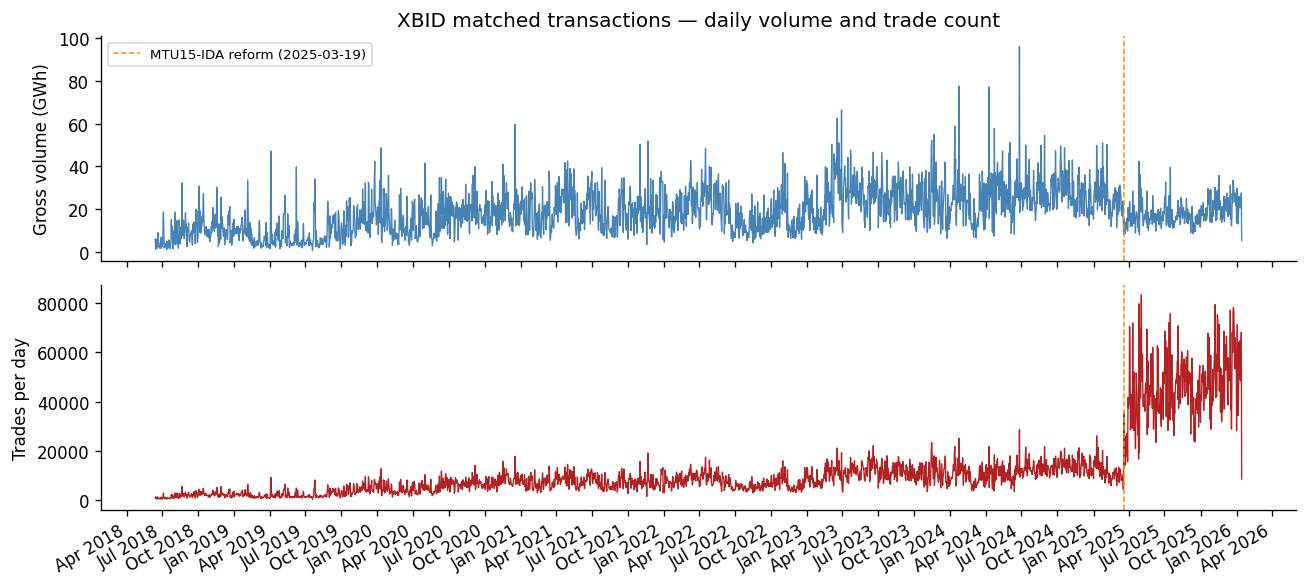

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Trade price distribution (EUR/MWh) by MTU regime:


,regime,p10,p25,p50,p75,p90,n_trades
0,MTU15,-2.39,8.59,59.99,90.13,110.10,13824724
1,MTU60,19.17,43.50,80.56,121.11,181.67,17982165


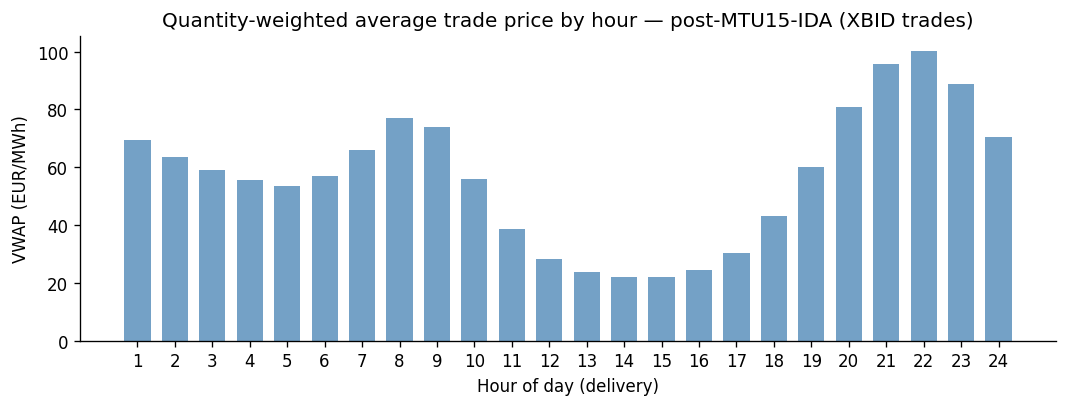

In [36]:
con_tr = duckdb.connect()
trades_path = str(TRADES)

# ── 10a. Coverage ─────────────────────────────────────────────────────────────
cov = con_tr.execute(f"""
    SELECT MIN(delivery_date)                              AS date_min,
           MAX(delivery_date)                              AS date_max,
           COUNT(DISTINCT delivery_date)                   AS n_delivery_days,
           COUNT(*)                                        AS n_trades,
           SUM(quantity_mw * mtu_minutes / 60.0) / 1e6    AS total_twh
    FROM read_parquet('{trades_path}')
""").fetchone()
print(f"Date range:    {cov[0]} \u2192 {cov[1]}")
print(f"Delivery days: {cov[2]:,}")
print(f"Total trades:  {cov[3]:,}")
print(f"Total TWh:     {cov[4]:.2f}")

# ── 10b. Daily volume and trade count over time ───────────────────────────────
daily_vol = con_tr.execute(f"""
    SELECT delivery_date::DATE                       AS date,
           SUM(quantity_mw * mtu_minutes / 60.0)    AS gross_mwh,
           COUNT(*)                                  AS n_trades
    FROM read_parquet('{trades_path}')
    GROUP BY delivery_date::DATE ORDER BY date
""").df()
daily_vol["date"] = pd.to_datetime(daily_vol["date"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax1.plot(daily_vol["date"], daily_vol["gross_mwh"] / 1e3, linewidth=0.8, color="steelblue")
ax1.set_ylabel("Gross volume (GWh)")
ax1.set_title("XBID matched transactions \u2014 daily volume and trade count")
ax1.axvline(INTRADAY_REFORM, color="darkorange", linewidth=0.9, linestyle="--",
            label="MTU15-IDA reform (2025-03-19)")
ax1.legend(fontsize=8)

ax2.plot(daily_vol["date"], daily_vol["n_trades"], linewidth=0.8, color="firebrick")
ax2.set_ylabel("Trades per day")
ax2.axvline(INTRADAY_REFORM, color="darkorange", linewidth=0.9, linestyle="--")
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ── 10c. VWAP distribution by regime ─────────────────────────────────────────
vwap_dist = con_tr.execute(f"""
    SELECT CASE WHEN mtu_minutes = 15 THEN 'MTU15' ELSE 'MTU60' END AS regime,
           PERCENTILE_CONT(0.10) WITHIN GROUP (ORDER BY price_eur_mwh) AS p10,
           PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY price_eur_mwh) AS p25,
           PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY price_eur_mwh) AS p50,
           PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY price_eur_mwh) AS p75,
           PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY price_eur_mwh) AS p90,
           COUNT(*) AS n_trades
    FROM read_parquet('{trades_path}')
    GROUP BY regime ORDER BY regime
""").df()
print("Trade price distribution (EUR/MWh) by MTU regime:")
display(vwap_dist)

# ── 10d. VWAP profile by hour of day — post-MTU15 ────────────────────────────
# Compare VWAP_{d,pi} vs DA clearing price p*_{d,pi} aggregated to hours
vwap_profile = con_tr.execute(f"""
    WITH post AS (
        SELECT delivery_date::DATE AS date,
               CEIL(period / 4.0)  AS hour,
               price_eur_mwh, quantity_mw
        FROM read_parquet('{trades_path}')
        WHERE mtu_minutes = 15
    )
    SELECT hour,
           SUM(price_eur_mwh * quantity_mw) / SUM(quantity_mw) AS vwap,
           COUNT(*) AS n_trades
    FROM post GROUP BY hour ORDER BY hour
""").df()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(vwap_profile["hour"], vwap_profile["vwap"],
       color="steelblue", alpha=0.75, width=0.7)
ax.set_xlabel("Hour of day (delivery)")
ax.set_ylabel("VWAP (EUR/MWh)")
ax.set_title("Quantity-weighted average trade price by hour \u2014 post-MTU15-IDA (XBID trades)")
ax.set_xticks(range(1, 25))
plt.tight_layout()
plt.show()


### §10b — Note: mechanical spike and efficiency interpretation

**Is the trades-per-day spike after the reform mechanical?** Largely yes. Before the MTU15-IDA reform each matched trade covers one 60-minute delivery period; after, one 15-minute period. The same energy rebalancing that required one trade execution pre-reform now requires up to four — so the raw trade count should rise by approximately 4× mechanically, even if the *amount* of energy repositioned is unchanged. The top panel (MWh-corrected volume) is the apples-to-apples comparison; the bottom panel (raw trades per day) reflects both the mechanical inflation and any genuine change in trading intensity.

**Is ‘fewer (normalised) trades + lower prices’ evidence of efficiency?** The interpretation is consistent but needs caveats:

- *Fewer per-period trades*: dividing post-reform daily trade count by 4 gives an effective per-period intensity. If that is lower than pre-reform, it suggests the day-ahead programme was better calibrated and less intraday correction was needed — consistent with finer DA granularity reducing scheduling error.
- *Lower XBID prices*: a lower average XBID price in the post-MTU15-IDA period is consistent with reduced urgency premiums when the DA schedule is more precise. However, XBID prices also reflect the fuel price and demand environment of the post-reform calendar months, which differ from the MTU60 period. A causal efficiency claim requires a regression discontinuity or seasonal controls.

**Quantity-weighted vs simple-average price** (next cell): if VWAP < simple average, large trades execute at a *discount* (market depth); if VWAP > simple average, large trades carry a *premium* (price impact / strategic execution).


VWAP vs simple-average trade price by MTU regime:


,regime,n_trades,simple_avg_eur_mwh,vwap_eur_mwh,vwap_minus_simple,price_std,avg_qty_mw
0,MTU15,13824724,54.21,55.29,1.07,47.77,1.574
1,MTU60,17982165,91.27,89.38,-1.89,68.56,2.549


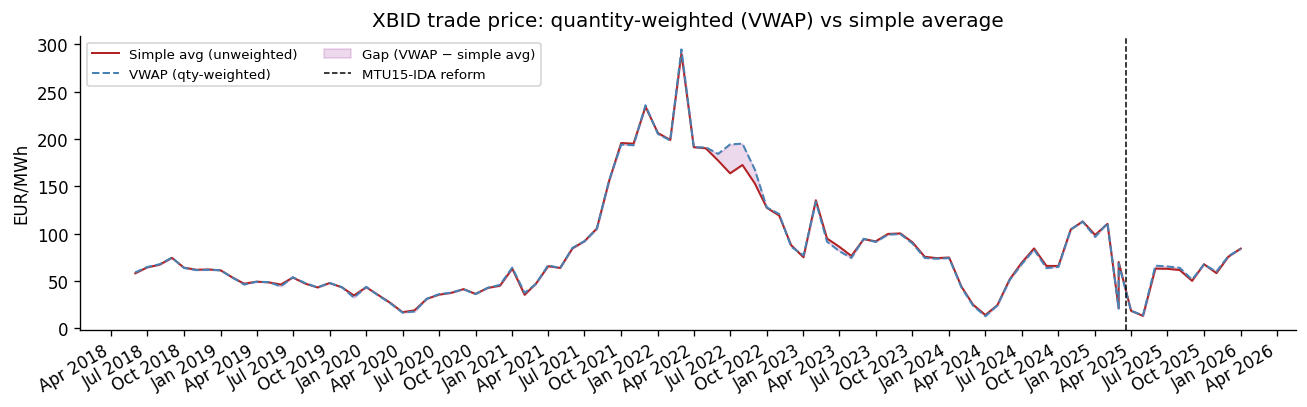

In [37]:
# Quantity-weighted (VWAP) vs unweighted average trade price by regime.
# VWAP = sum(p_k * q_k) / sum(q_k)   <- large trades count more
# Simple avg = sum(p_k) / n_k           <- each execution counts equally
# VWAP - simple_avg > 0  ->  large trades at higher price (price impact)
# VWAP - simple_avg < 0  ->  large trades at lower price (volume discount / depth)

price_compare = con_tr.execute(f"""
    SELECT
        CASE WHEN mtu_minutes = 15 THEN 'MTU15' ELSE 'MTU60' END        AS regime,
        COUNT(*)                                                          AS n_trades,
        ROUND(AVG(price_eur_mwh), 2)                                     AS simple_avg_eur_mwh,
        ROUND(SUM(price_eur_mwh * quantity_mw) / SUM(quantity_mw), 2)   AS vwap_eur_mwh,
        ROUND(SUM(price_eur_mwh * quantity_mw) / SUM(quantity_mw)
              - AVG(price_eur_mwh), 2)                                   AS vwap_minus_simple,
        ROUND(STDDEV(price_eur_mwh), 2)                                  AS price_std,
        ROUND(AVG(quantity_mw), 3)                                       AS avg_qty_mw
    FROM read_parquet('{trades_path}')
    GROUP BY regime ORDER BY regime
""").df()

print("VWAP vs simple-average trade price by MTU regime:")
display(price_compare)

# Monthly VWAP vs simple average
price_monthly = con_tr.execute(f"""
    SELECT
        DATE_TRUNC('month', delivery_date::DATE)                         AS month,
        CASE WHEN mtu_minutes = 15 THEN 'MTU15' ELSE 'MTU60' END        AS regime,
        ROUND(AVG(price_eur_mwh), 2)                                     AS simple_avg,
        ROUND(SUM(price_eur_mwh * quantity_mw) / SUM(quantity_mw), 2)   AS vwap
    FROM read_parquet('{trades_path}')
    GROUP BY month, regime ORDER BY month
""").df()
price_monthly["month"] = pd.to_datetime(price_monthly["month"])

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(price_monthly["month"], price_monthly["simple_avg"], color="firebrick",
        linewidth=1.2, label="Simple avg (unweighted)")
ax.plot(price_monthly["month"], price_monthly["vwap"], color="steelblue",
        linewidth=1.2, linestyle="--", label="VWAP (qty-weighted)")
ax.fill_between(price_monthly["month"], price_monthly["simple_avg"], price_monthly["vwap"],
                alpha=0.15, color="purple", label="Gap (VWAP − simple avg)")
ax.axvline(INTRADAY_REFORM, color="black", linewidth=0.9, linestyle="--",
           label="MTU15-IDA reform")
ax.set_ylabel("EUR/MWh")
ax.set_title("XBID trade price: quantity-weighted (VWAP) vs simple average")
ax.legend(fontsize=8, ncol=2)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()


---

## Section 11 — Firm concentration across markets

Three new per-firm program families (`pdbce`, `pibcie`, `pibcice`) carry OMIE's competition-watched `grupo_empresarial` codes (**IB, GN, GE, HC, EHN, REP, EGL, DET**) directly. This section uses them to track whether the reforms altered *who* clears the Spanish wholesale market, not just *how* clearing occurs. Chang (2026) reports analogous firm-count and Top-N descriptives (her Table 2) for the Australian NEM.

**Object.** Let $s_{f,m,t}$ be firm $f$'s share of cleared MWh in market $m \in \{\text{DA, IDA, Continuous}\}$ in month $t$:

$$ s_{f,m,t} \;=\; \frac{|Q_{f,m,t}|}{\sum_g |Q_{g,m,t}|}, \qquad \text{HHI}_{m,t} \;=\; 10\,000 \cdot \sum_f s_{f,m,t}^2, \qquad \text{Top5}_{m,t} \;=\; \sum_{f \in \text{top 5}(m,t)} s_{f,m,t}. $$

We aggregate $|Q_{f,m,t}| = \sum_{d \in t, p} |\text{power}_{f,d,p}| \cdot \Delta t_p$ over delivery dates $d$ and dispatch periods $p$ in month $t$ (absolute values so buy-side and sell-side activity both count as market presence). `pibcice` uses `grupo_short` (always the parent code); the other two use `grupo_empresarial` directly.

**Data scope.** `pdbce` and `pibcie` end 2025-09-30; `pibcice` ends 2025-10-01. The DA15/ID15 regime (post 2025-10-01 DA) is not yet visible in these tables, so the series stop before the October 2025 reform.


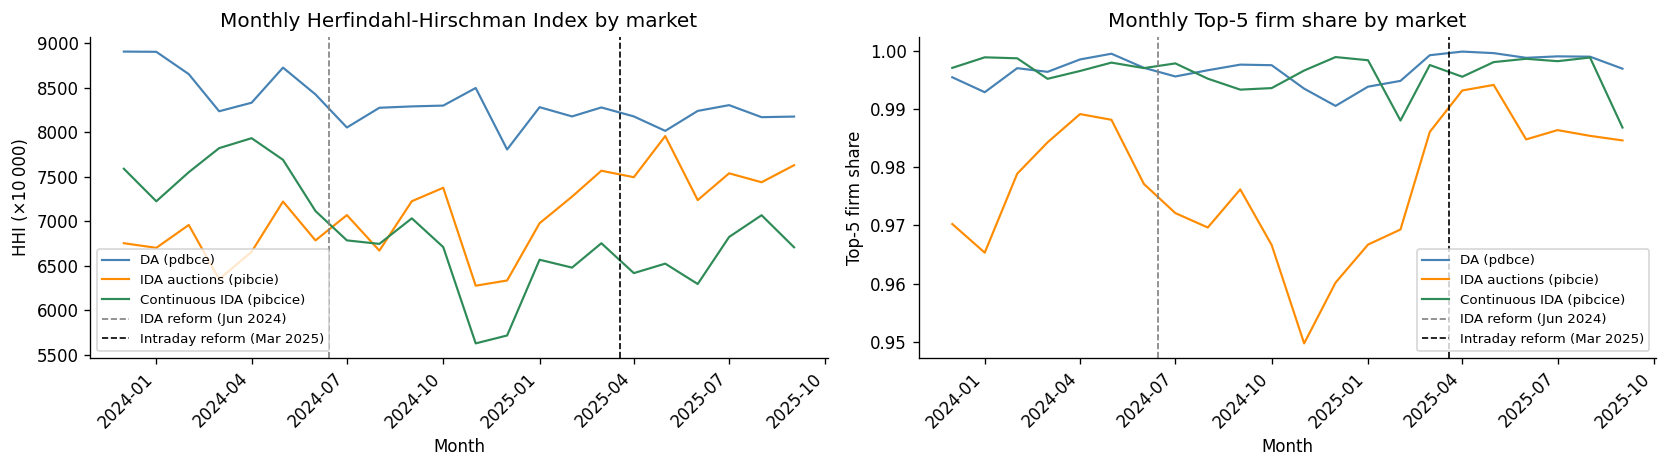

                         HHI                           Top5                        
                          DA IDA auctions Continuous     DA IDA auctions Continuous
Pre IDA (<2024-06)  8598.001     6774.676   7560.928  0.997        0.979      0.997
Post IDA reform     8218.171     6974.654   6490.520  0.995        0.969      0.995
Post MTU15-IDA      8180.874     7549.412   6638.926  0.999        0.988      0.996


In [38]:
PDBCE   = PROJECT_ROOT / 'data/processed/omie/mercado_diario/programas/pdbce_all.parquet'
PIBCIE  = PROJECT_ROOT / 'data/processed/omie/mercado_intradiario_subastas/programas/pibcie_all.parquet'
PIBCICE = PROJECT_ROOT / 'data/processed/omie/mercado_intradiario_continuo/programas/pibcice_all.parquet'

CONC_START = '2023-12-01'
CONC_END   = '2025-09-30'

con_firm = duckdb.connect()

def _firm_month(parquet_path, firm_col):
    return con_firm.execute(f"""
        SELECT DATE_TRUNC('month', CAST(date AS DATE)) AS month,
               COALESCE({firm_col}, 'Fringe')          AS firm,
               SUM(ABS(assigned_power_mw) * mtu_minutes / 60.0) AS mwh
        FROM read_parquet('{parquet_path}')
        WHERE CAST(date AS DATE) BETWEEN '{CONC_START}' AND '{CONC_END}'
        GROUP BY 1, 2
    """).df()

def _conc_stats(fm):
    fm = fm.copy()
    fm['month'] = pd.to_datetime(fm['month'])
    rows = []
    for m, g in fm.groupby('month'):
        total = g['mwh'].sum()
        if total <= 0:
            continue
        shares = g['mwh'] / total
        rows.append({'month': m,
                     'HHI':  float((shares ** 2).sum() * 10_000),
                     'Top5': float(shares.nlargest(5).sum())})
    return pd.DataFrame(rows).sort_values('month').reset_index(drop=True)

da_conc   = _conc_stats(_firm_month(str(PDBCE),   'grupo_empresarial'))
ida_conc  = _conc_stats(_firm_month(str(PIBCIE),  'grupo_empresarial'))
cont_conc = _conc_stats(_firm_month(str(PIBCICE), 'grupo_short'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for df, lbl, color in [(da_conc,   'DA (pdbce)',              'steelblue'),
                       (ida_conc,  'IDA auctions (pibcie)',    'darkorange'),
                       (cont_conc, 'Continuous IDA (pibcice)', 'seagreen')]:
    axes[0].plot(df['month'], df['HHI'],  linewidth=1.3, label=lbl, color=color)
    axes[1].plot(df['month'], df['Top5'], linewidth=1.3, label=lbl, color=color)

for ax, ylbl, ttl in [(axes[0], 'HHI (\u00d710\u2009000)', 'Monthly Herfindahl-Hirschman Index by market'),
                      (axes[1], 'Top-5 firm share',          'Monthly Top-5 firm share by market')]:
    ax.axvline(IDA_REFORM,      color='gray',    linestyle='--', linewidth=1, label='IDA reform (Jun 2024)')
    ax.axvline(ISP15_REFORM,    color='#e07b39', linestyle='--', linewidth=1, label='ISP15 (Dec 2024)')
    ax.axvline(INTRADAY_REFORM, color='black',   linestyle='--', linewidth=1, label='Intraday reform (Mar 2025)')
    ax.set_xlabel('Month'); ax.set_ylabel(ylbl); ax.set_title(ttl)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()

# compact regime summary
def _regime_mean(df, col):
    return {
        'Pre IDA (<2024-06)':       df.loc[df['month']  < IDA_REFORM, col].mean(),
        'Post IDA / Pre-ISP15':     df.loc[(df['month'] >= IDA_REFORM) & (df['month'] < ISP15_REFORM), col].mean(),
        'ISP15 window':             df.loc[(df['month'] >= ISP15_REFORM) & (df['month'] < INTRADAY_REFORM), col].mean(),
        'Post MTU15-IDA':           df.loc[df['month'] >= INTRADAY_REFORM, col].mean(),
    }
summary = pd.DataFrame({
    ('HHI',  'DA'):             _regime_mean(da_conc,   'HHI'),
    ('HHI',  'IDA auctions'):   _regime_mean(ida_conc,  'HHI'),
    ('HHI',  'Continuous'):     _regime_mean(cont_conc, 'HHI'),
    ('Top5', 'DA'):             _regime_mean(da_conc,   'Top5'),
    ('Top5', 'IDA auctions'):   _regime_mean(ida_conc,  'Top5'),
    ('Top5', 'Continuous'):     _regime_mean(cont_conc, 'Top5'),
})
print(summary.round(3).to_string())


**Reading the panels.** The left panel tracks HHI (0–10 000; 10 000 = monopoly); the right panel tracks the combined share of the five largest firms. A flat series across regime boundaries means the reform reshuffled quantities *within* each firm rather than between firms. A rise (fall) signals concentration (deconcentration) of market presence.

**Caveat on scope.** `grupo_short`/`grupo_empresarial` label only the eight competition-watched groups; all unlabeled units fall into a residual `Fringe` bucket. If reforms shift activity toward many small new entrants, the Fringe share can grow but HHI barely moves — both statistics are complementary, not substitutes.


---

## Section 12 — Supply-function slope at the clearing price

For each delivery hour we measure how price-responsive the aggregate supply is at the margin, using the full (uncleared) DA offer curve from `curva_pbc`. Chang (2026) reports a fall in slope from 3.79 MW / (AU\$/MWh) to 2.45 MW / (AU\$/MWh) after the 5MS reform, interpreted as reduced price responsiveness; we compute the analogous object for Spain across the three regime breaks.

**Object.** Let $S_t(p)$ be the total quantity offered at price $\le p$ in period $t$, built by cumulative-summing `curva_pbc` sell-side rows (`curve_type='O'`, `offer_type='V'`) ordered by price. Given clearing price $P^{*}_t$ from `marginalpdbc`, the local slope is

$$ \hat\sigma_t \;=\; \frac{S_t(P^{*}_t + h) - S_t(P^{*}_t - h)}{2h} \qquad \text{(MW per EUR/MWh),} $$

with window $h = 2$ EUR/MWh. We sample one period per day (MTU60: period 12; MTU15: period 45, both ≈ 11:00-12:00 local) to cap computation, then take monthly means. Pure description — no inference.


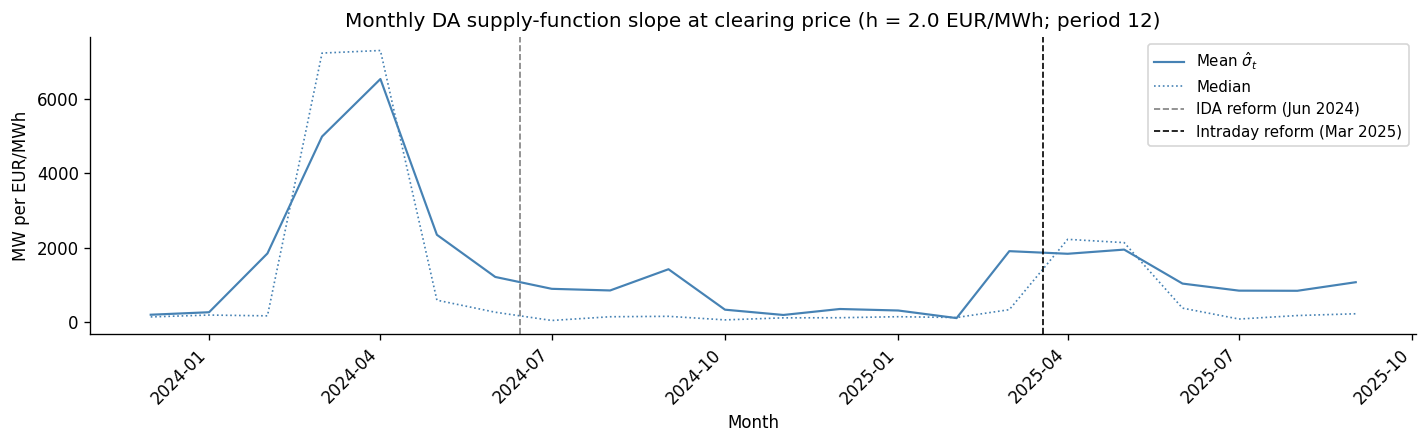

Mean DA supply-slope at P* by regime (MW per EUR/MWh):
  Pre IDA (<2024-06-14)           2482.982
  Post IDA (3-sess)               701.580
  Post MTU15-IDA                  1258.559


In [39]:
CURVA_PBC = PROJECT_ROOT / 'data/processed/omie/mercado_diario/curvas/curva_pbc_all.parquet'

SLOPE_H     = 2.0
SLOPE_START = '2023-12-01'
SLOPE_END   = '2025-09-30'
SAMPLE_PERIOD = 12  # hour-12 (~ noon) — DA stays MTU60 through 2025-09-30

con_slope = duckdb.connect()
slope_q = f"""
WITH clearing AS (
    SELECT CAST(m.date AS DATE) AS date,
           CAST(m.period AS INT) AS period,
           m.price_es_eur_mwh    AS pstar
    FROM read_parquet('{MARGINALPDBC}') m
    WHERE CAST(m.date AS DATE) BETWEEN '{SLOPE_START}' AND '{SLOPE_END}'
      AND m.period = {SAMPLE_PERIOD}
      AND m.price_es_eur_mwh IS NOT NULL
),
supply AS (
    SELECT CAST(c.date AS DATE)   AS date,
           TRY_CAST(c.period_raw AS INT) AS period,
           c.price_eur_mwh        AS price,
           c.power_mw             AS power
    FROM read_parquet('{CURVA_PBC}') c
    WHERE c.curve_type = 'O' AND c.offer_type = 'V'
      AND CAST(c.date AS DATE) BETWEEN '{SLOPE_START}' AND '{SLOPE_END}'
      AND TRY_CAST(c.period_raw AS INT) = {SAMPLE_PERIOD}
)
SELECT cl.date, cl.pstar,
       SUM(CASE WHEN s.price <= cl.pstar + {SLOPE_H} THEN s.power ELSE 0 END) AS q_hi,
       SUM(CASE WHEN s.price <= cl.pstar - {SLOPE_H} THEN s.power ELSE 0 END) AS q_lo
FROM clearing cl
JOIN supply s ON s.date = cl.date AND s.period = cl.period
GROUP BY cl.date, cl.pstar
"""

slope_df = con_slope.execute(slope_q).df()
slope_df['slope'] = (slope_df['q_hi'] - slope_df['q_lo']) / (2 * SLOPE_H)
slope_df['date']  = pd.to_datetime(slope_df['date'])
slope_df['month'] = slope_df['date'].dt.to_period('M').dt.to_timestamp()

monthly_slope = (
    slope_df.groupby('month')['slope']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(monthly_slope['month'], monthly_slope['mean'],   linewidth=1.3, color='steelblue', label='Mean $\\hat\\sigma_t$')
ax.plot(monthly_slope['month'], monthly_slope['median'], linewidth=1.0, color='steelblue', linestyle=':', label='Median')
ax.axvline(IDA_REFORM,      color='gray',    linestyle='--', linewidth=1, label='IDA reform (Jun 2024)')
ax.axvline(ISP15_REFORM,    color='#e07b39', linestyle='--', linewidth=1, label='ISP15 (Dec 2024)')
ax.axvline(INTRADAY_REFORM, color='black',   linestyle='--', linewidth=1, label='Intraday reform (Mar 2025)')
ax.set_xlabel('Month'); ax.set_ylabel('MW per EUR/MWh')
ax.set_title(f'Monthly DA supply-function slope at clearing price (h = {SLOPE_H} EUR/MWh; period {SAMPLE_PERIOD})')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# regime-mean summary
cuts = [('Pre IDA (<2024-06-14)',    monthly_slope['month'] <  IDA_REFORM),
        ('Post IDA / Pre-ISP15',      (monthly_slope['month'] >= IDA_REFORM) & (monthly_slope['month'] < ISP15_REFORM)),
        ('ISP15 window',               (monthly_slope['month'] >= ISP15_REFORM) & (monthly_slope['month'] < INTRADAY_REFORM)),
        ('Post MTU15-IDA',             monthly_slope['month'] >= INTRADAY_REFORM)]
print('Mean DA supply-slope at P* by regime (MW per EUR/MWh):')
for name, mask in cuts:
    print(f'  {name:30s}  {monthly_slope.loc[mask, "mean"].mean():.3f}')


**Reading the chart.** A higher $\hat\sigma_t$ means more MW offered within ±2 EUR/MWh of the clearing price — i.e. a flatter local supply curve, more price-responsive bidding at the margin. A post-reform drop would be the Spanish analogue of Chang's finding that 5MS flattened *and then steepened* the local supply curve (her mechanism: settlement-rule change altering perceived residual-demand elasticity). Spain's reforms have no 1/T analogue, so any trend here reflects composition / gaming / capacity-mix changes, not a settlement mechanism — treat as descriptive only.

**Caveats.** (1) The one-period-per-day sample captures shoulder-morning conditions and is not a trading-day average — reading hour-level aggregation from this number would be inappropriate. (2) Slope units flip with horizontal/vertical conventions; this is the inverse-demand slope (quantity per EUR/MWh) for consistency with Ito-Reguant's supply-function framing.
